# Spatial Cluster Analysis of NYC Shooting Incidents

**Dataset:** NYPD Shooting Incident Data (Historic), 2006–2022  
**Unit of analysis:** Shooting incident  
**Goal:** Examine the spatial distribution of NYC shooting incidents and compare partition-based and density-based clustering methods.

### Analysis steps

1. Load and inspect the dataset
2. Check missing values, duplicates, and coordinates
3. Perform basic exploratory data analysis
4. Create an incident-level dataset
5. Apply K-Means as a baseline
6. Apply DBSCAN and HDBSCAN
7. Compare the clustering results
8. Analyse the final clusters by time, severity, and location

**Note:** Internal clustering metrics are used to understand individual models, but they are not treated as a single score for comparing different algorithms. Geographic structure and the purpose of the analysis are also considered.


## Step 1 — Import libraries

Libraries are grouped by the role they play in the analysis. Only libraries actually used downstream are imported, so that the dependency list of the notebook is an accurate statement of what the analysis requires.

`HDBSCAN` requires scikit-learn 1.3 or later. `NearestNeighbors` is imported here because it is used to construct the k-distance plot from which the DBSCAN `eps` parameter is selected.

In [1]:
# --- Data handling ---
import pandas as pd
import numpy as np

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Clustering models ---
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN

# --- Parameter selection ---
from sklearn.neighbors import NearestNeighbors

# --- Cluster validation metrics ---
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries imported.")

Libraries imported.


## Step 2 — Load the dataset

The file is read with `low_memory=False` so that pandas infers each column's dtype from the full column rather than from chunks, which avoids mixed-dtype warnings on the sparsely populated descriptive fields.

In [2]:
df = pd.read_csv('NYPD_Shooting_Incident_Data__Historic_.csv', low_memory=False)

print("Raw dataset loaded.")
print("Shape:", df.shape)

Raw dataset loaded.
Shape: (27312, 21)


## Step 3 — Inspect the first records

A first look at the raw structure, to confirm the file has loaded as expected and to see the format of the date, time and coordinate fields before any conversion is attempted.

In [3]:
df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,NaN,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,NaN,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,NaN,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,NaN,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,25-44,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


## Step 4 — Dataset dimensions

The row count here is the number of *victim-level records*, not the number of shooting incidents. The distinction is established formally in Step 9 and resolved in Step 21.

In [4]:
df.shape

(27312, 21)

## Step 5 — Column names

The dataset carries four location representations: `BORO` and `PRECINCT` (administrative), `X_COORD_CD`/`Y_COORD_CD` (projected), and `Latitude`/`Longitude`/`Lon_Lat` (geographic). Which of these is appropriate for distance-based clustering is addressed in Step 22.

In [5]:
df.columns

Index(['INCIDENT_KEY', 'OCCUR_DATE', 'OCCUR_TIME', 'BORO', 'LOC_OF_OCCUR_DESC',
       'PRECINCT', 'JURISDICTION_CODE', 'LOC_CLASSFCTN_DESC', 'LOCATION_DESC',
       'STATISTICAL_MURDER_FLAG', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
       'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'X_COORD_CD', 'Y_COORD_CD',
       'Latitude', 'Longitude', 'Lon_Lat'],
      dtype='object')

## Step 6 — Dataset information

Non-null counts and dtypes for every column. This identifies which fields are sparsely populated and which will need type conversion before use.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_SEX               

## Step 7 — Missing values by column

An absolute count of missing values per column.

In [7]:
df.isnull().sum()

INCIDENT_KEY                   0
OCCUR_DATE                     0
OCCUR_TIME                     0
BORO                           0
LOC_OF_OCCUR_DESC          25596
PRECINCT                       0
JURISDICTION_CODE              2
LOC_CLASSFCTN_DESC         25596
LOCATION_DESC              14977
STATISTICAL_MURDER_FLAG        0
PERP_AGE_GROUP              9344
PERP_SEX                    9310
PERP_RACE                   9310
VIC_AGE_GROUP                  0
VIC_SEX                        0
VIC_RACE                       0
X_COORD_CD                     0
Y_COORD_CD                     0
Latitude                      10
Longitude                     10
Lon_Lat                       10
dtype: int64

## Step 8 — Missing values as a percentage

The proportional view identifies which columns are unusable. Fields describing the location classification and the perpetrator are substantially incomplete; the fields required for spatial clustering are effectively complete. This is the first indication that the analysis should be built on the coordinate fields rather than on the descriptive location fields.

In [8]:
missing_percentage = df.isnull().mean() * 100
missing_percentage.sort_values(ascending=False)

LOC_OF_OCCUR_DESC          93.717047
LOC_CLASSFCTN_DESC         93.717047
LOCATION_DESC              54.836702
PERP_AGE_GROUP             34.212068
PERP_RACE                  34.087581
PERP_SEX                   34.087581
Longitude                   0.036614
Latitude                    0.036614
Lon_Lat                     0.036614
JURISDICTION_CODE           0.007323
STATISTICAL_MURDER_FLAG     0.000000
OCCUR_DATE                  0.000000
PRECINCT                    0.000000
VIC_AGE_GROUP               0.000000
VIC_SEX                     0.000000
VIC_RACE                    0.000000
X_COORD_CD                  0.000000
Y_COORD_CD                  0.000000
BORO                        0.000000
OCCUR_TIME                  0.000000
INCIDENT_KEY                0.000000
dtype: float64

## Step 9 — Duplicate records

Two distinct questions are asked here, and they have different answers:

- **Duplicate rows** — whether any record is repeated in full.
- **Duplicate incident keys** — whether the same `INCIDENT_KEY` appears more than once.

A repeated `INCIDENT_KEY` is not a data error. Each row in this dataset represents one *victim*; a shooting with three victims produces three rows sharing one incident key. This is the central structural fact about the dataset and it determines the unit of analysis used from Step 21 onward.

In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate incident IDs:", df['INCIDENT_KEY'].duplicated().sum())

Duplicate rows: 0
Duplicate incident IDs: 5892


## Step 10 — Geographic fields

A preview and a five-number summary of the latitude and longitude columns, to confirm that the values fall within the plausible bounding box for New York City.

In [10]:
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,40.662965,-73.730839
1,40.810352,-73.924942
2,40.742607,-73.915492
3,40.837782,-73.919457
4,40.886238,-73.852910


In [11]:
df[['Latitude', 'Longitude']].describe()

,Latitude,Longitude
count,27302.000000,27302.000000
mean,40.737892,-73.909051
std,0.087525,0.066272
min,40.511586,-74.249303
25%,40.668481,-73.943027
50%,40.700318,-73.915221
75%,40.824067,-73.882330
max,40.910818,-73.702046


## Step 11 — Missing coordinates

The count of records lacking geographic coordinates. Because clustering is distance-based, any record without usable coordinates must either be recovered from an alternative field or excluded.

In [12]:
df[['Latitude', 'Longitude']].isnull().sum()

Latitude     10
Longitude    10
dtype: int64

## Step 12 — Consolidated missing-value summary

Counts and percentages presented together, sorted by severity, as a single reference table for the data-quality section of the report.

In [13]:
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': (missing / len(df)) * 100
})

missing_summary.sort_values(by='Missing_Percentage', ascending=False)

,Missing_Count,Missing_Percentage
LOC_OF_OCCUR_DESC,25596,93.717047
LOC_CLASSFCTN_DESC,25596,93.717047
LOCATION_DESC,14977,54.836702
PERP_AGE_GROUP,9344,34.212068
PERP_RACE,9310,34.087581
PERP_SEX,9310,34.087581
Longitude,10,0.036614
Latitude,10,0.036614
Lon_Lat,10,0.036614
JURISDICTION_CODE,2,0.007323


## Step 13 — Records with missing coordinates

The individual records lacking latitude and longitude are inspected rather than dropped immediately, because the dataset carries a second, independent coordinate representation that may still be populated for these rows.

In [14]:
df[df[['Latitude', 'Longitude']].isnull().any(axis=1)]

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
1406,250584475,09/03/2022,22:45:00,BROOKLYN,OUTSIDE,90,0.0,STREET,(null),False,(null),(null),(null),18-24,F,WHITE HISPANIC,998002.0,196692.0,NaN,NaN,NaN
25597,259091227,12/19/2022,23:23:00,BROOKLYN,OUTSIDE,60,0.0,STREET,(null),False,25-44,M,BLACK,25-44,M,BLACK,990784.0,149362.0,NaN,NaN,NaN
25598,251253188,09/18/2022,03:40:00,MANHATTAN,OUTSIDE,34,0.0,STREET,(null),False,(null),(null),(null),18-24,M,BLACK HISPANIC,1002173.0,249401.0,NaN,NaN,NaN
25832,254053457,11/13/2022,01:00:00,QUEENS,OUTSIDE,110,0.0,PLAYGROUND,(null),False,18-24,M,WHITE HISPANIC,25-44,M,WHITE HISPANIC,1019164.0,210169.0,NaN,NaN,NaN
25938,252281471,10/09/2022,19:15:00,BROOKLYN,OUTSIDE,61,0.0,HOUSING,MULTI DWELL - PUBLIC HOUS,False,<18,M,WHITE HISPANIC,25-44,M,BLACK,995122.0,155693.0,NaN,NaN,NaN
26273,251690448,09/27/2022,23:30:00,MANHATTAN,OUTSIDE,28,0.0,STREET,(null),False,18-24,M,BLACK,18-24,M,BLACK,997407.0,233806.0,NaN,NaN,NaN
26741,251690448,09/27/2022,23:30:00,MANHATTAN,OUTSIDE,28,0.0,STREET,(null),False,18-24,M,BLACK,25-44,M,BLACK,997407.0,233806.0,NaN,NaN,NaN
26814,255042633,12/03/2022,10:21:00,MANHATTAN,OUTSIDE,33,0.0,STREET,(null),False,(null),(null),(null),18-24,M,BLACK HISPANIC,1001891.0,245600.0,NaN,NaN,NaN
26875,250460651,09/01/2022,01:15:00,QUEENS,OUTSIDE,103,0.0,OTHER,(null),False,(null),(null),(null),18-24,M,BLACK,1041717.0,197008.0,NaN,NaN,NaN
27205,250340401,08/30/2022,00:10:00,BROOKLYN,OUTSIDE,84,0.0,STREET,(null),False,(null),(null),(null),25-44,F,BLACK,988902.0,192641.0,NaN,NaN,NaN


## Step 14 — Coordinate recovery check

The same records are examined with the projected coordinates alongside the geographic ones. If `X_COORD_CD` and `Y_COORD_CD` are populated where `Latitude` and `Longitude` are not, then no record needs to be discarded — the analysis simply has to be built on the projected coordinate pair.

In [15]:
df[
    df[['Latitude', 'Longitude']].isnull().any(axis=1)
][[
    'INCIDENT_KEY',
    'X_COORD_CD',
    'Y_COORD_CD',
    'Latitude',
    'Longitude',
    'BORO'
]]

,INCIDENT_KEY,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,BORO
1406,250584475,998002.0,196692.0,NaN,NaN,BROOKLYN
25597,259091227,990784.0,149362.0,NaN,NaN,BROOKLYN
25598,251253188,1002173.0,249401.0,NaN,NaN,MANHATTAN
25832,254053457,1019164.0,210169.0,NaN,NaN,QUEENS
25938,252281471,995122.0,155693.0,NaN,NaN,BROOKLYN
26273,251690448,997407.0,233806.0,NaN,NaN,MANHATTAN
26741,251690448,997407.0,233806.0,NaN,NaN,MANHATTAN
26814,255042633,1001891.0,245600.0,NaN,NaN,MANHATTAN
26875,250460651,1041717.0,197008.0,NaN,NaN,QUEENS
27205,250340401,988902.0,192641.0,NaN,NaN,BROOKLYN


## Step 15 — Incident count versus record count

The gap between the total row count and the number of unique incident keys quantifies the victim-level structure identified in Step 9, and gives the size of the incident-level dataset that will be constructed in Step 21.

In [16]:
print("Total rows:", len(df))
print("Unique incident IDs:", df['INCIDENT_KEY'].nunique())
print("Duplicate incident IDs:", df['INCIDENT_KEY'].duplicated().sum())

Total rows: 27312
Unique incident IDs: 21420
Duplicate incident IDs: 5892


# Step 16 — Exploratory data analysis

Six views of the raw data, covering its administrative, temporal, demographic and geographic dimensions. These establish the baseline distributions against which the cluster solutions are later interpreted.

The charts in this section are computed on the **victim-level** data. They describe the distribution of victims, which is the appropriate frame for the demographic charts. The spatial analysis from Step 21 onward switches to the incident level.

### Chart 1 — Records by borough

This chart shows how the shooting records are distributed across the five boroughs. It provides a basic geographic overview before clustering.


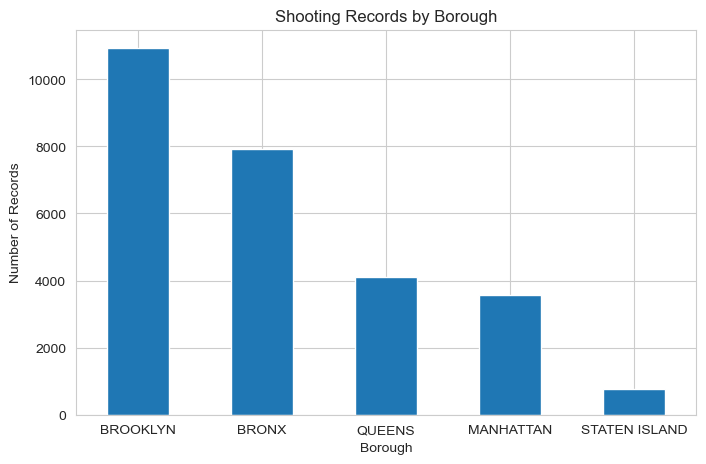

In [17]:
plt.figure(figsize=(8, 5))

df['BORO'].value_counts().plot(kind='bar')

plt.title('Shooting Records by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

### Chart 2 — Records over time

`OCCUR_DATE` is converted to a datetime and resampled to month-end frequency. This reveals the long-run trend across the 2006–2022 period, including any structural breaks.

In [18]:
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'])

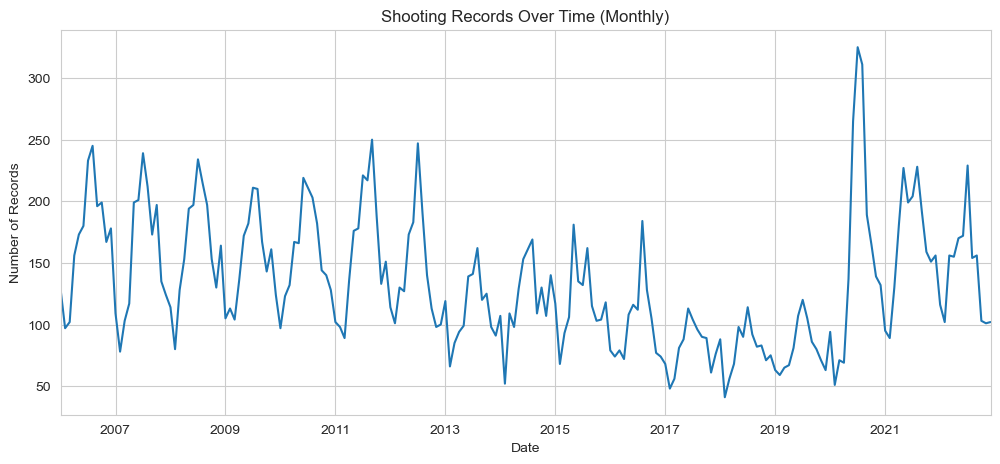

In [19]:
monthly_shootings = (
    df.set_index('OCCUR_DATE')
      .resample('ME')
      .size()
)

plt.figure(figsize=(12, 5))
monthly_shootings.plot()

plt.title('Shooting Records Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.show()

### Chart 3 — Records by hour of day

This chart shows the distribution of incidents by hour. The same time information is used later for the cluster-level temporal analysis.


In [20]:
df['HOUR'] = pd.to_datetime(
    df['OCCUR_TIME'],
    format='%H:%M:%S'
).dt.hour

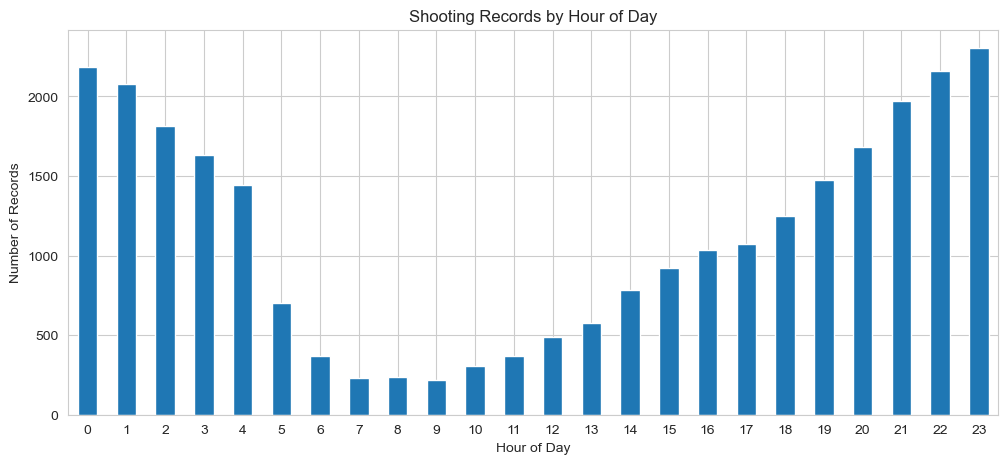

In [21]:
hourly_shootings = df['HOUR'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
hourly_shootings.plot(kind='bar')

plt.title('Shooting Records by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

### Chart 4 — Victim age groups

The age distribution of victims. Note that this chart is valid only at the victim level; it must not be recomputed on the deduplicated incident-level dataset, for the reason set out in Step 21.

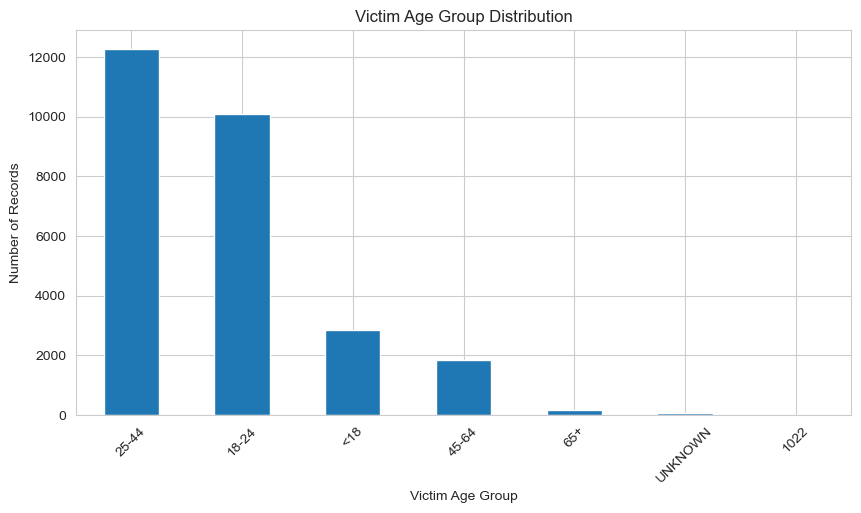

In [22]:
plt.figure(figsize=(10, 5))

df['VIC_AGE_GROUP'].value_counts().plot(kind='bar')

plt.title('Victim Age Group Distribution')
plt.xlabel('Victim Age Group')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

### Chart 5 — Raw geographic distribution

A scatter of every record in latitude/longitude space, with low opacity so that overplotting itself conveys density. The visible shape of the city — separated landmasses with dense interior concentrations — is the structure the clustering models will be attempting to describe, and it already suggests that a partitioning model and a density model will return very different answers.

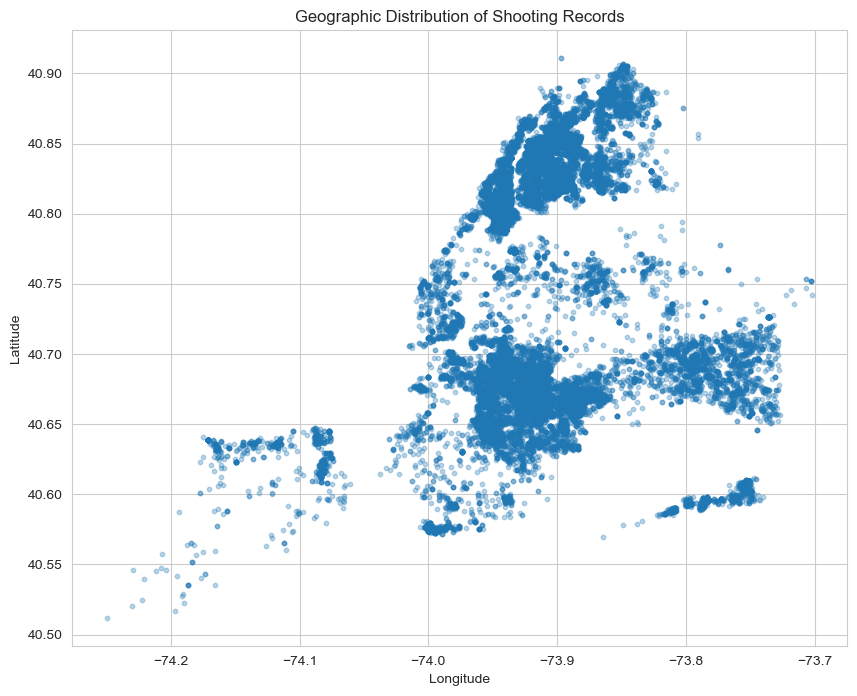

In [23]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.3,
    s=10
)

plt.title('Geographic Distribution of Shooting Records')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Chart 6 — Victim sex distribution

The final demographic view. As with Chart 4, this is a victim-level statistic.

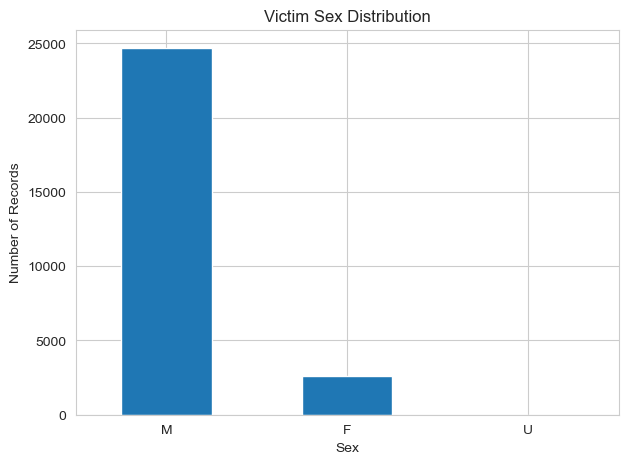

In [24]:
plt.figure(figsize=(7, 5))

df['VIC_SEX'].value_counts().plot(kind='bar')

plt.title('Victim Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

# Step 17 — Pre-clustering validation: spatial consistency within incidents

Before collapsing victim-level rows into incident-level rows, it must be established that the collapse does not destroy information. The first requirement is that every `INCIDENT_KEY` corresponds to exactly one location. If a single incident key carried two different coordinates, selecting one arbitrarily would introduce spatial error into the clustering input.

This check counts the number of distinct latitude and longitude values within each incident key.

In [25]:
incident_location_check = (
    df.groupby('INCIDENT_KEY')
      .agg(
          unique_latitude=('Latitude', 'nunique'),
          unique_longitude=('Longitude', 'nunique')
      )
)

incident_location_check.head()

,unique_latitude,unique_longitude
INCIDENT_KEY,,
9953245,1,1
9953246,1,1
9953247,1,1
9953248,1,1
9953249,1,1


In [26]:
multiple_locations = incident_location_check[
    (incident_location_check['unique_latitude'] > 1) |
    (incident_location_check['unique_longitude'] > 1)
]

print("Total unique incidents:", len(incident_location_check))
print("Incidents with multiple locations:", len(multiple_locations))

Total unique incidents: 21420
Incidents with multiple locations: 0


## Step 18 — Incident-level spatial dataset

A one-row-per-incident geographic table is built from both coordinate representations, and the completeness of each is compared directly. The representation with full coverage is the one the clustering will use.

In [27]:
incident_geo = (
    df[['INCIDENT_KEY', 'Latitude', 'Longitude']]
    .drop_duplicates('INCIDENT_KEY')
    .copy()
)

print("Incident-level geographic dataset shape:", incident_geo.shape)
print("Missing Latitude:", incident_geo['Latitude'].isna().sum())
print("Missing Longitude:", incident_geo['Longitude'].isna().sum())

Incident-level geographic dataset shape: (21420, 3)
Missing Latitude: 9
Missing Longitude: 9


In [28]:
incident_geo_xy = (
    df[['INCIDENT_KEY', 'X_COORD_CD', 'Y_COORD_CD']]
    .drop_duplicates('INCIDENT_KEY')
    .copy()
)

print("Incident-level projected dataset shape:", incident_geo_xy.shape)
print("Missing X coordinates:", incident_geo_xy['X_COORD_CD'].isna().sum())
print("Missing Y coordinates:", incident_geo_xy['Y_COORD_CD'].isna().sum())

Incident-level projected dataset shape: (21420, 3)
Missing X coordinates: 0
Missing Y coordinates: 0


## Step 19 — Validate the consistency of duplicate incident keys

Step 17 confirmed that locations are consistent within an incident. This step extends the same test to every field that the incident-level dataset will inherit: date, time, both projected coordinates, borough and precinct.

If all six counts return zero, then taking the first row of each incident key is **lossless with respect to these fields**, and the deduplication in Step 21 is safe for the purposes of spatial and temporal analysis. The fields this test does *not* cover are the victim-level demographics, which necessarily vary within an incident — that limitation is handled in Step 20.

In [29]:
duplicate_incidents = df[df['INCIDENT_KEY'].duplicated(keep=False)].copy()

consistency_check = (
    duplicate_incidents
    .groupby('INCIDENT_KEY')
    .agg(
        Date_Unique=('OCCUR_DATE', 'nunique'),
        Time_Unique=('OCCUR_TIME', 'nunique'),
        X_Unique=('X_COORD_CD', 'nunique'),
        Y_Unique=('Y_COORD_CD', 'nunique'),
        Boro_Unique=('BORO', 'nunique'),
        Precinct_Unique=('PRECINCT', 'nunique')
    )
)

print("Duplicate incident IDs checked:", len(consistency_check))
print("\nIncidents with different dates:", (consistency_check['Date_Unique'] > 1).sum())
print("Incidents with different times:", (consistency_check['Time_Unique'] > 1).sum())
print("Incidents with different X coordinates:", (consistency_check['X_Unique'] > 1).sum())
print("Incidents with different Y coordinates:", (consistency_check['Y_Unique'] > 1).sum())
print("Incidents with different boroughs:", (consistency_check['Boro_Unique'] > 1).sum())
print("Incidents with different precincts:", (consistency_check['Precinct_Unique'] > 1).sum())

Duplicate incident IDs checked: 3521

Incidents with different dates: 0
Incidents with different times: 0
Incidents with different X coordinates: 0
Incidents with different Y coordinates: 0
Incidents with different boroughs: 0
Incidents with different precincts: 0


## Step 20 — Preserve victim count before deduplication

Deduplication to one row per incident discards the additional victim records. Those rows are not redundant: they carry the information that an incident involved more than one victim.

Two things are done here, and both must happen **before** the deduplication in Step 21:

1. The number of victims per incident is computed and retained as `N_VICTIMS`. This becomes a severity weight — it allows a hotspot to be characterised not only by how many incidents occurred there, but by how many people were shot.
2. The magnitude of what deduplication removes is quantified explicitly, so that the limitation is documented rather than silent.

The consequence to carry forward: `incident_df` is the correct frame for spatial and temporal analysis, and the **wrong** frame for victim demographics. Any demographic breakdown must be computed on `df`.

In [30]:
victim_counts = (
    df.groupby('INCIDENT_KEY')
      .size()
      .rename('N_VICTIMS')
)

print("Victim-level records:", len(df))
print("Unique incidents:", len(victim_counts))
print("Additional victim records removed by deduplication:",
      len(df) - len(victim_counts))

print("\nVictims per incident:")
print(victim_counts.value_counts().sort_index())

print("\nMulti-victim incidents:",
      (victim_counts > 1).sum(),
      f"({(victim_counts > 1).mean() * 100:.2f}% of incidents)")

Victim-level records: 27312
Unique incidents: 21420
Additional victim records removed by deduplication: 5892

Victims per incident:
N_VICTIMS
1     17899
2      2489
3       313
4       531
5        10
6        95
7         2
8        57
9         2
10        3
12       18
18        1
Name: count, dtype: int64

Multi-victim incidents: 3521 (16.44% of incidents)


## Step 21 — Construct the incident-level dataset

The dataset is sorted by `INCIDENT_KEY` before deduplication so that the row retained for each incident is deterministic rather than dependent on file order — this makes the notebook reproducible. Step 19 established that the retained row is identical to the discarded ones for every field used downstream.

`N_VICTIMS` from Step 20 is merged back on, so the incident-level table carries the severity information that deduplication would otherwise have destroyed.

In [31]:
incident_df = (
    df
    .sort_values('INCIDENT_KEY')
    .drop_duplicates('INCIDENT_KEY')
    .copy()
)

incident_df = incident_df.merge(
    victim_counts,
    on='INCIDENT_KEY',
    how='left'
)

print("Victim-level shape:", df.shape)
print("Incident-level shape:", incident_df.shape)
print("Unique incident IDs:", incident_df['INCIDENT_KEY'].nunique())

print("\nMissing coordinates in clustering input:")
print("X_COORD_CD:", incident_df['X_COORD_CD'].isna().sum())
print("Y_COORD_CD:", incident_df['Y_COORD_CD'].isna().sum())

print("\nTotal victims represented:", int(incident_df['N_VICTIMS'].sum()))

Victim-level shape: (27312, 22)
Incident-level shape: (21420, 23)
Unique incident IDs: 21420

Missing coordinates in clustering input:
X_COORD_CD: 0
Y_COORD_CD: 0

Total victims represented: 27312


## Step 22 — Coordinate reference system and units

The projected coordinates `X_COORD_CD` and `Y_COORD_CD` are used for spatial clustering. They are measured in US survey feet, so distances such as DBSCAN `eps` can be interpreted as physical distances.

| Feet | Metres | Approximate distance |
|---:|---:|---|
| 500 | 152 | Short distance |
| 1,000 | 305 | About two blocks |
| 1,250 | 381 | About two to three blocks |
| 2,000 | 610 | About five blocks |

Latitude and longitude are not used for distance calculations because they are angular coordinates. The projected coordinates are also complete for the records used in the analysis.


In [32]:
FEET_TO_METRES = 0.3048006096012192  # US survey foot

print("Coordinate extent (feet):")
print(incident_df[['X_COORD_CD', 'Y_COORD_CD']].describe().round(0))

x_range_ft = incident_df['X_COORD_CD'].max() - incident_df['X_COORD_CD'].min()
y_range_ft = incident_df['Y_COORD_CD'].max() - incident_df['Y_COORD_CD'].min()

print("\nEast-west extent:  %.1f miles" % (x_range_ft * FEET_TO_METRES / 1609.344))
print("North-south extent: %.1f miles" % (y_range_ft * FEET_TO_METRES / 1609.344))
print("\n(Sanity check: NYC spans roughly 30 miles east-west.)")

Coordinate extent (feet):
       X_COORD_CD  Y_COORD_CD
count     21420.0     21420.0
mean    1009482.0    207387.0
std       18472.0     31752.0
min      914928.0    125757.0
25%      999994.0    182660.0
50%     1007627.0    193586.0
75%     1016947.0    239075.0
max     1066815.0    271128.0

East-west extent:  28.8 miles
North-south extent: 27.5 miles

(Sanity check: NYC spans roughly 30 miles east-west.)


## Step 23 — Prepare the spatial feature matrix

The clustering input is the projected coordinate pair, one row per incident.

In [33]:
spatial_features = incident_df[['X_COORD_CD', 'Y_COORD_CD']].copy()

print("Spatial feature shape:", spatial_features.shape)
print("\nSummary statistics:")
print(spatial_features.describe())

Spatial feature shape: (21420, 2)

Summary statistics:
         X_COORD_CD     Y_COORD_CD
count  2.142000e+04   21420.000000
mean   1.009482e+06  207387.160468
std    1.847228e+04   31751.674888
min    9.149281e+05  125756.718750
25%    9.999939e+05  182660.406250
50%    1.007627e+06  193586.046875
75%    1.016947e+06  239074.875000
max    1.066815e+06  271127.687500


## Step 24 — Why the coordinates are not standardised

The two clustering features are both geographic coordinates measured in the same unit. They are therefore kept on their original scale.

Standardising them would change the relative scale of the two axes and would make the resulting distances less directly interpretable as physical distance.


In [34]:
x_std = incident_df['X_COORD_CD'].std()
y_std = incident_df['Y_COORD_CD'].std()

print("X standard deviation: %.0f feet" % x_std)
print("Y standard deviation: %.0f feet" % y_std)
print("\nRatio (Y / X): %.2f" % (y_std / x_std))
print("\nStandardising would compress the north-south axis by a factor of")
print("%.2f relative to east-west, distorting all ground distances." % (y_std / x_std))

X standard deviation: 18472 feet
Y standard deviation: 31752 feet

Ratio (Y / X): 1.72

Standardising would compress the north-south axis by a factor of
1.72 relative to east-west, distorting all ground distances.


## Step 25 — Clustering input matrix

The feature matrix is converted to a NumPy array for the scikit-learn estimators.

In [35]:
X_spatial = incident_df[['X_COORD_CD', 'Y_COORD_CD']].values

print("Clustering data shape:", X_spatial.shape)
print("\nFirst 5 records:")
print(X_spatial[:5])

Clustering data shape: (21420, 2)

First 5 records:
[[1013404.5625   251800.75   ]
 [1007418.       243859.21875]
 [ 999316.       176460.     ]
 [1028604.625    187929.5    ]
 [1000067.125    198310.78125]]


## Step 26 — Visualise the incident-level spatial distribution

The clustering input plotted in its own coordinate space. Compared with Chart 5, this view is deduplicated and undistorted by the latitude/longitude projection, so it is the true geometry the algorithms will operate on.

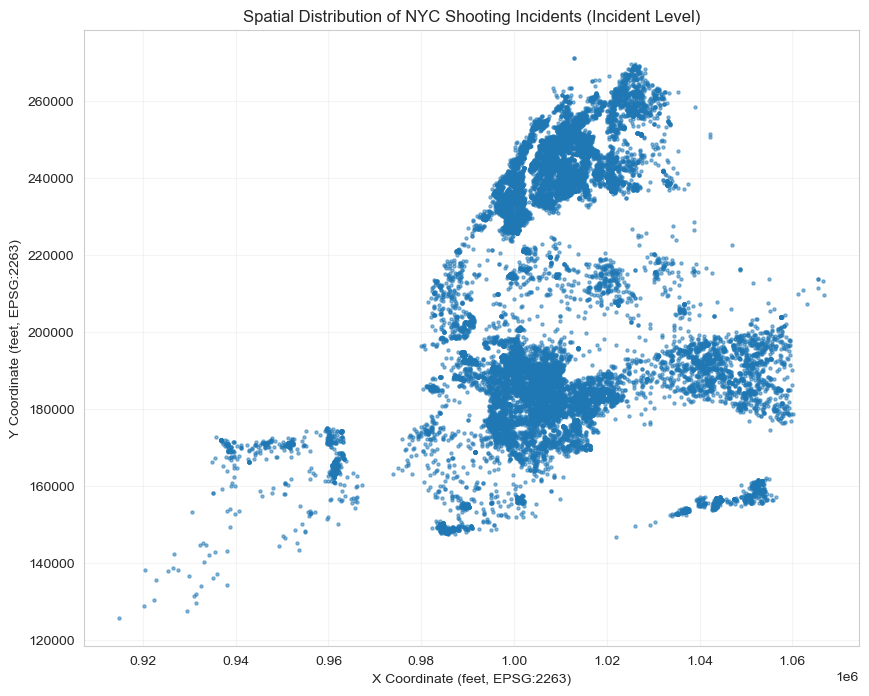

In [36]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_spatial[:, 0],
    X_spatial[:, 1],
    s=5,
    alpha=0.5
)

plt.xlabel("X Coordinate (feet, EPSG:2263)")
plt.ylabel("Y Coordinate (feet, EPSG:2263)")
plt.title("Spatial Distribution of NYC Shooting Incidents (Incident Level)")
plt.grid(True, alpha=0.2)
plt.show()

# Step 27 — K-Means baseline

K-Means is used as a baseline model. It divides the observations into a fixed number of clusters using their distance from cluster centroids.

This is useful for comparison, but K-Means assigns every incident to a cluster and does not specifically model local density. The results are therefore checked against the existing borough information before moving to density-based methods.


### Step 27a — Silhouette scores across candidate K

K from 2 to 10 is evaluated by silhouette score. Within the K-Means family this comparison is valid, because every candidate shares the same convexity assumption.

In [37]:
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_spatial)
    score = silhouette_score(X_spatial, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

c:\Users\DELL\.conda\envs\tensorflow\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\DELL\.conda\envs\tensorflow\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\DELL\.conda\envs\tensorflow\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\DELL\.conda\envs\tensorflow\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\DELL\.conda\envs\tensorflow\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(exec

K = 2, Silhouette Score = 0.6026
K = 3, Silhouette Score = 0.6056
K = 4, Silhouette Score = 0.6135
K = 5, Silhouette Score = 0.5058
K = 6, Silhouette Score = 0.3985
K = 7, Silhouette Score = 0.4174
K = 8, Silhouette Score = 0.4319
K = 9, Silhouette Score = 0.4272
K = 10, Silhouette Score = 0.4414


### Step 27b — Plot the silhouette curve

The visual form of the curve matters as much as the maximum: a sharp peak indicates a well-separated structure, while a flat profile indicates that the choice of K is weakly determined by the data.

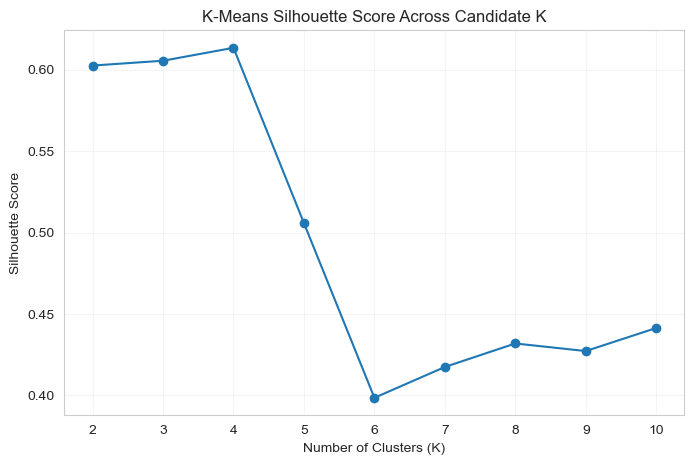

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score Across Candidate K")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.2)
plt.show()

## Step 28 — Elbow method

The elbow method plots K-Means inertia for different values of K. A noticeable change in the rate of decrease can help identify a suitable number of clusters.

The plot is considered together with the silhouette results rather than being used on its own.


In [39]:
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_spatial)
    inertia_values.append(kmeans.inertia_)

print("K-Means inertia:")
for k, inertia in zip(k_values, inertia_values):
    print(f"K = {k}, Inertia = {inertia:.2f}")

print("\nPercentage reduction from previous K:")
for i in range(1, len(inertia_values)):
    drop = (inertia_values[i-1] - inertia_values[i]) / inertia_values[i-1] * 100
    print(f"K = {list(k_values)[i]}: {drop:.1f}% reduction")

K-Means inertia:
K = 2, Inertia = 10406142401333.53
K = 3, Inertia = 6364838676872.37
K = 4, Inertia = 4595888757010.06
K = 5, Inertia = 3587613389472.83
K = 6, Inertia = 3073315088380.00
K = 7, Inertia = 2546079513711.13
K = 8, Inertia = 2137108551657.71
K = 9, Inertia = 1834692231603.98
K = 10, Inertia = 1596701423116.93

Percentage reduction from previous K:
K = 3: 38.8% reduction
K = 4: 27.8% reduction
K = 5: 21.9% reduction
K = 6: 14.3% reduction
K = 7: 17.2% reduction
K = 8: 16.1% reduction
K = 9: 14.2% reduction
K = 10: 13.0% reduction


### Step 28a — Plot the elbow curve

The percentage-reduction figures printed above should be read alongside this plot. A genuine elbow appears as a step change in those percentages, not merely as a visually curved line — the curve will always look bent because inertia falls on a large absolute scale.

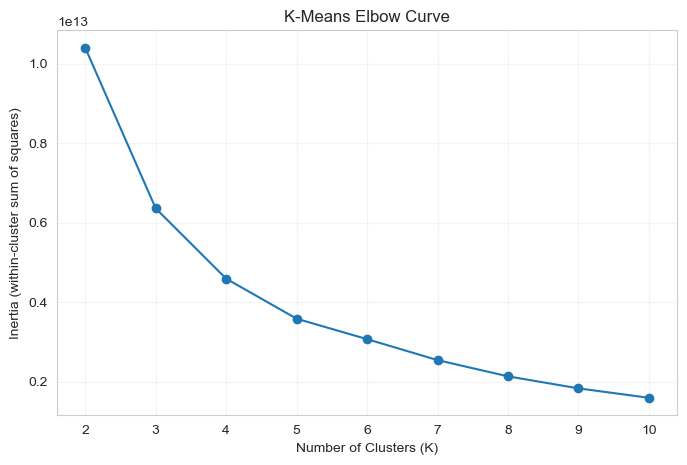

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia_values, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("K-Means Elbow Curve")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.2)
plt.show()

## Step 29 — Fit the K-Means baseline

K = 4 is fitted, following the silhouette result from Step 27a. `n_init=10` runs the algorithm from ten independent initialisations and retains the lowest-inertia solution, which guards against convergence to a poor local optimum; `random_state=42` fixes the result for reproducibility.

In [41]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_spatial)

print("Number of clusters:", len(set(kmeans_labels)))
print("\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nCluster sizes as percentage:")
print((pd.Series(kmeans_labels).value_counts(normalize=True).sort_index() * 100).round(2))

Number of clusters: 4

Cluster sizes:
0    1089
1    2479
2    9050
3    8802
Name: count, dtype: int64

Cluster sizes as percentage:
0     5.08
1    11.57
2    42.25
3    41.09
Name: proportion, dtype: float64


## Step 30 — Visualise the K-Means partition

The cluster assignments plotted in coordinate space. The expected appearance is four contiguous regions with straight boundaries between them — the Voronoi structure described in Step 27. Straight, arbitrary-looking boundaries cutting through dense areas are not a defect of the fit; they are what a partitioning algorithm necessarily produces.

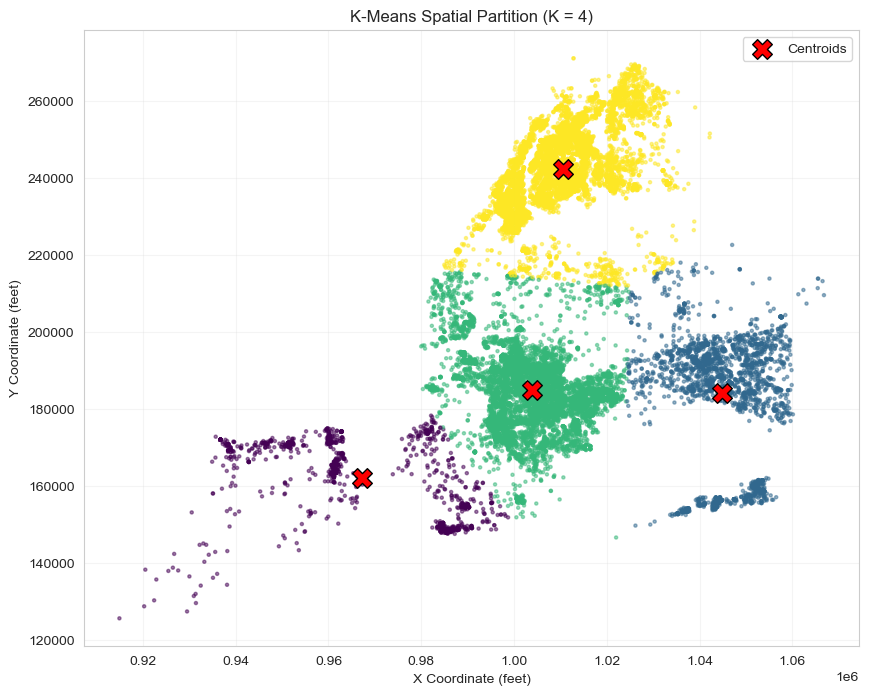

In [42]:
plt.figure(figsize=(10, 8))

plt.scatter(
    X_spatial[:, 0],
    X_spatial[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=5,
    alpha=0.5
)

plt.scatter(
    kmeans_final.cluster_centers_[:, 0],
    kmeans_final.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    edgecolors='black',
    label='Centroids'
)

plt.xlabel("X Coordinate (feet)")
plt.ylabel("Y Coordinate (feet)")
plt.title("K-Means Spatial Partition (K = 4)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Step 31 — Evaluate the K-Means solution

The K-Means solution is evaluated using three internal metrics:

- **Silhouette Score:** higher values indicate better separation and cohesion.
- **Davies–Bouldin Index:** lower values indicate better separation.
- **Calinski–Harabasz Index:** higher values indicate stronger between-cluster separation relative to within-cluster variation.

These metrics describe the K-Means solution. The relationship between the clusters and the boroughs is checked separately in Step 34.


In [43]:
silhouette_k4 = silhouette_score(X_spatial, kmeans_labels)
davies_bouldin_k4 = davies_bouldin_score(X_spatial, kmeans_labels)
calinski_harabasz_k4 = calinski_harabasz_score(X_spatial, kmeans_labels)

print("K-Means Evaluation (K = 4)")
print("-" * 34)
print(f"Silhouette Score:        {silhouette_k4:.4f}")
print(f"Davies-Bouldin Index:    {davies_bouldin_k4:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_k4:.2f}")

K-Means Evaluation (K = 4)
----------------------------------
Silhouette Score:        0.6135
Davies-Bouldin Index:    0.6113
Calinski-Harabasz Index: 37755.06


## Step 32 — Cluster stability across random initialisations

K-Means is run with five different random seeds. The Adjusted Rand Index (ARI) is used to compare the resulting cluster labels.

An ARI close to 1 means that the partitions are very similar. This checks the stability of the model, not whether the clusters are substantively meaningful.


In [44]:
seeds = [0, 10, 20, 30, 40]
stability_labels = []

for seed in seeds:
    kmeans = KMeans(n_clusters=4, random_state=seed, n_init=10)
    stability_labels.append(kmeans.fit_predict(X_spatial))

reference_labels = stability_labels[0]
ari_scores = []

for i in range(1, len(stability_labels)):
    ari = adjusted_rand_score(reference_labels, stability_labels[i])
    ari_scores.append(ari)
    print(f"Seed {seeds[i]:>2} vs Seed {seeds[0]}  ARI: {ari:.4f}")

print("\nAverage ARI:", round(sum(ari_scores) / len(ari_scores), 4))

Seed 10 vs Seed 0  ARI: 1.0000
Seed 20 vs Seed 0  ARI: 1.0000
Seed 30 vs Seed 0  ARI: 1.0000
Seed 40 vs Seed 0  ARI: 1.0000

Average ARI: 1.0


## Step 33 — Cluster profiling

Each cluster is described by its size, its share of all incidents, its geographic centre, and — using `N_VICTIMS` from Step 20 — the number of victims it accounts for. Including the victim count distinguishes clusters that contain many incidents from clusters that contain the most severe ones.

In [45]:
incident_df['KMeans_Cluster'] = kmeans_labels

cluster_profile = (
    incident_df
    .groupby('KMeans_Cluster')
    .agg(
        Incident_Count=('INCIDENT_KEY', 'count'),
        Total_Victims=('N_VICTIMS', 'sum'),
        Mean_Victims=('N_VICTIMS', 'mean'),
        Mean_X=('X_COORD_CD', 'mean'),
        Mean_Y=('Y_COORD_CD', 'mean')
    )
    .reset_index()
)

cluster_profile['Pct_Incidents'] = (
    cluster_profile['Incident_Count'] / len(incident_df) * 100
)

print(cluster_profile.round(2))

   KMeans_Cluster  Incident_Count  Total_Victims  Mean_Victims      Mean_X  \
0               0            1089           1384          1.27   967333.16   
1               1            2479           3108          1.25  1044942.63   
2               2            9050          11303          1.25  1003840.65   
3               3            8802          11517          1.31  1010509.27   

      Mean_Y  Pct_Incidents  
0  162220.48           5.08  
1  184310.78          11.57  
2  184968.53          42.25  
3  242524.79          41.09  


## Step 34 — Does the K-Means partition recover anything beyond the boroughs?

The K-Means labels are compared with `BORO` using the Adjusted Rand Index and a cross-tabulation.

This helps determine whether K-Means is finding a structure beyond the borough boundaries already present in the dataset.


In [46]:
borough_cluster = pd.crosstab(
    incident_df['KMeans_Cluster'],
    incident_df['BORO']
)

print("Incident count by cluster and borough:")
print(borough_cluster)

borough_cluster_pct = pd.crosstab(
    incident_df['KMeans_Cluster'],
    incident_df['BORO'],
    normalize='index'
) * 100

print("\nPercentage composition within each cluster:")
print(borough_cluster_pct.round(2))

Incident count by cluster and borough:
BORO            BRONX  BROOKLYN  MANHATTAN  QUEENS  STATEN ISLAND
KMeans_Cluster                                                   
0                   0       470          0       0            619
1                   0         0          0    2479              0
2                   0      8336        377     337              0
3                6019         0       2370     413              0

Percentage composition within each cluster:
BORO            BRONX  BROOKLYN  MANHATTAN  QUEENS  STATEN ISLAND
KMeans_Cluster                                                   
0                0.00     43.16       0.00    0.00          56.84
1                0.00      0.00       0.00  100.00           0.00
2                0.00     92.11       4.17    3.72           0.00
3               68.38      0.00      26.93    4.69           0.00


In [47]:
boro_codes = incident_df['BORO'].astype('category').cat.codes

ari_kmeans_boro = adjusted_rand_score(boro_codes, kmeans_labels)

print("Adjusted Rand Index, K-Means (K=4) vs BORO: %.4f" % ari_kmeans_boro)
print()
print("Interpretation scale:")
print("  ~0.00  cluster labels are unrelated to borough")
print("  ~0.50  substantial but partial correspondence")
print("  ~1.00  the clustering has reproduced the boroughs")

print("\nDominant borough within each cluster:")
for c in sorted(borough_cluster_pct.index):
    row = borough_cluster_pct.loc[c]
    print(f"  Cluster {c}: {row.idxmax()} ({row.max():.1f}%)")

Adjusted Rand Index, K-Means (K=4) vs BORO: 0.6952

Interpretation scale:
  ~0.00  cluster labels are unrelated to borough
  ~0.50  substantial but partial correspondence
  ~1.00  the clustering has reproduced the boroughs

Dominant borough within each cluster:
  Cluster 0: STATEN ISLAND (56.8%)
  Cluster 1: QUEENS (100.0%)
  Cluster 2: BROOKLYN (92.1%)
  Cluster 3: BRONX (68.4%)


### Step 34a — Interpretation of the baseline

The ARI and cluster composition table are used together to interpret the K-Means baseline. If the clusters closely match the boroughs, then much of the spatial separation is explained by the existing city geography.

This provides the reason for testing density-based methods, which can identify groups based on local concentration instead of assigning every point to a centroid-based region.


# Step 35 — Temporal characteristics of the spatial clusters

The clusters were formed on coordinates alone, with no temporal input. Examining their temporal profiles therefore tests something the model was not fitted to: whether spatially distinct parts of the city also differ in *when* incidents occur.

Three views are produced — annual, monthly and hourly. Divergent profiles would indicate that geography and timing interact; near-identical profiles would indicate that the temporal pattern is a city-wide phenomenon that the spatial partition does not differentiate. Either result is informative.

In [48]:
incident_df['OCCUR_DATE'] = pd.to_datetime(
    incident_df['OCCUR_DATE'],
    errors='coerce'
)

incident_df['Year'] = incident_df['OCCUR_DATE'].dt.year
incident_df['Month'] = incident_df['OCCUR_DATE'].dt.month

incident_df['Hour'] = pd.to_datetime(
    incident_df['OCCUR_TIME'].astype(str),
    format='%H:%M:%S',
    errors='coerce'
).dt.hour

print("Temporal features created.")
print(incident_df[['OCCUR_DATE', 'OCCUR_TIME', 'Year', 'Month', 'Hour']].head())

Temporal features created.
  OCCUR_DATE OCCUR_TIME  Year  Month  Hour
0 2006-01-01   02:00:00  2006      1     2
1 2006-01-01   05:51:00  2006      1     5
2 2006-01-01   03:30:00  2006      1     3
3 2006-01-01   19:00:00  2006      1    19
4 2006-01-02   00:49:00  2006      1     0


## Step 36 — Validate the temporal conversion

`errors='coerce'` converts any unparseable value to `NaT` silently rather than raising. Because Step 7 established that `OCCUR_DATE` and `OCCUR_TIME` are complete in the source, any missing values appearing after conversion would indicate a **parsing failure**, not a data-quality issue.

This check is run immediately after the conversion and before the temporal features are used, so that a format mismatch cannot propagate silently into the profiling results.

In [49]:
print("Missing OCCUR_DATE after conversion:", incident_df['OCCUR_DATE'].isna().sum())
print("Missing Year after conversion:", incident_df['Year'].isna().sum())
print("Missing Month after conversion:", incident_df['Month'].isna().sum())
print("Missing Hour after conversion:", incident_df['Hour'].isna().sum())

assert incident_df['OCCUR_DATE'].isna().sum() == 0, "Date parsing failed"
assert incident_df['Hour'].isna().sum() == 0, "Time parsing failed"
print("\nConversion validated: no values lost to parsing.")

Missing OCCUR_DATE after conversion: 0
Missing Year after conversion: 0
Missing Month after conversion: 0
Missing Hour after conversion: 0

Conversion validated: no values lost to parsing.


### Step 36a — Annual distribution by cluster

Incident counts per year within each cluster. Of particular interest is whether the well-documented city-wide increase in 2020 appears uniformly across clusters or concentrates in particular areas.

In [50]:
year_cluster = pd.crosstab(incident_df['Year'], incident_df['KMeans_Cluster'])
print(year_cluster)

KMeans_Cluster   0    1    2    3
Year                             
2006            68  190  690  618
2007            66  154  668  554
2008            74  196  672  578
2009            79  173  614  554
2010            59  162  648  604
2011            72  177  645  615
2012            64  184  559  566
2013            79  123  481  420
2014            66  119  522  465
2015            75  120  482  461
2016            59  128  431  379
2017            58   94  295  342
2018            28   82  319  325
2019            45   85  306  341
2020            70  175  688  598
2021            64  176  553  769
2022            63  141  477  613


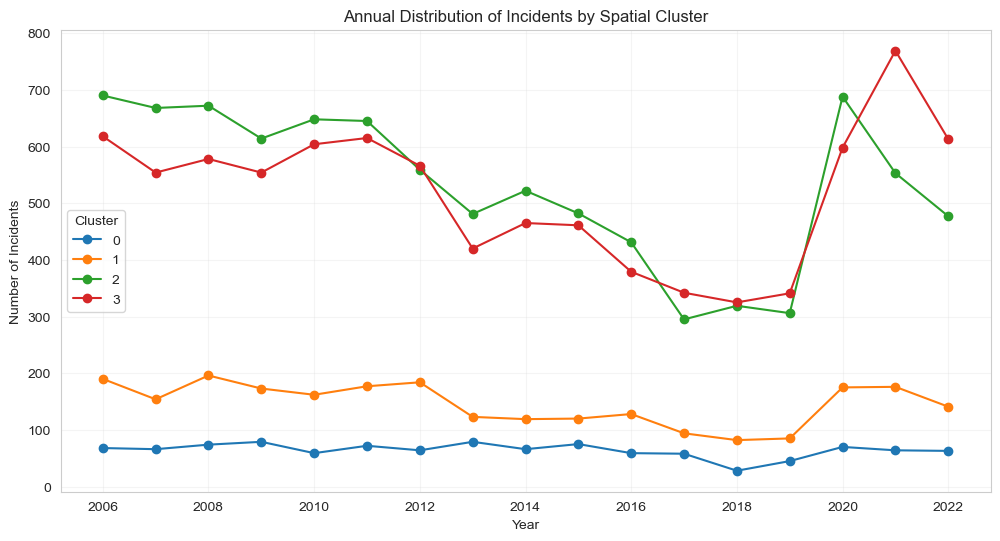

In [51]:
year_cluster.plot(figsize=(12, 6), marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.title("Annual Distribution of Incidents by Spatial Cluster")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.2)
plt.show()

### Step 36b — Monthly distribution by cluster

The seasonal profile. Because clusters differ substantially in size, the shape of each line matters more than its height — the question is whether the clusters share a seasonal pattern, not whether one has more incidents overall.

In [52]:
month_cluster = pd.crosstab(incident_df['Month'], incident_df['KMeans_Cluster'])
print(month_cluster)

KMeans_Cluster    0    1     2     3
Month                               
1                82  157   548   582
2                60  154   413   428
3                69  166   580   514
4                75  173   667   668
5                95  224   857   794
6               101  266   899   944
7               127  270  1092  1010
8               114  280  1058  1009
9                95  230   892   798
10               81  214   771   723
11               91  160   635   647
12               99  185   638   685


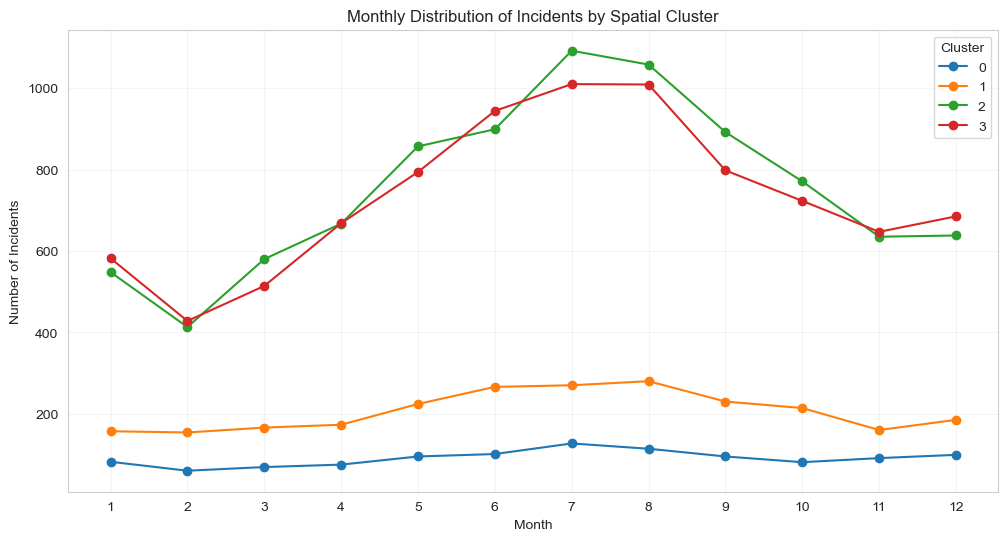

In [53]:
month_cluster.plot(kind='line', marker='o', figsize=(12, 6))

plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.title("Monthly Distribution of Incidents by Spatial Cluster")
plt.xticks(range(1, 13))
plt.legend(title="Cluster")
plt.grid(True, alpha=0.2)
plt.show()

### Step 36c — Monthly distribution, normalised within cluster

The same data expressed as each cluster's percentage share across months. Normalising removes the size difference between clusters, so the seasonal *shapes* can be compared directly. If the normalised lines overlap, the seasonal pattern is city-wide rather than cluster-specific.

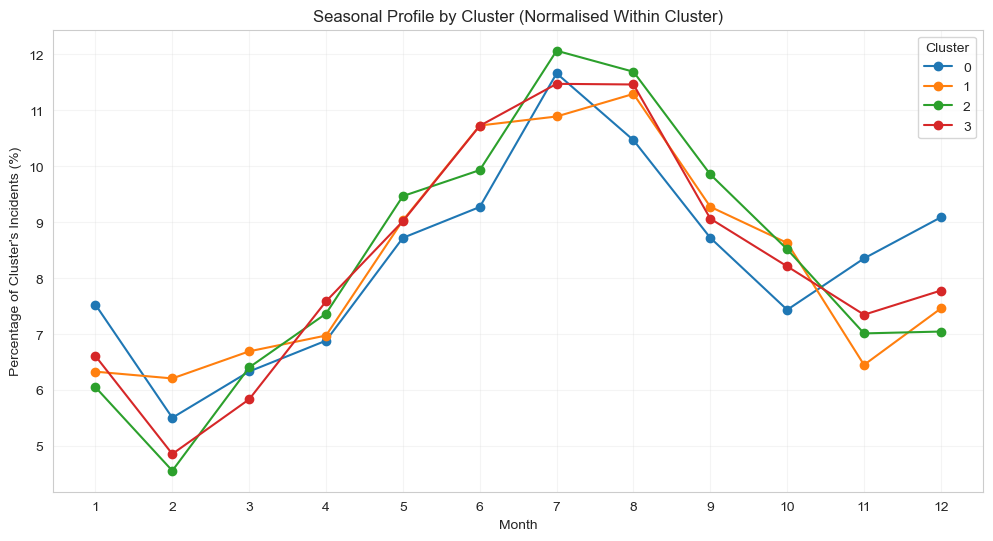

In [54]:
month_cluster_pct = month_cluster.div(month_cluster.sum(axis=0), axis=1) * 100

month_cluster_pct.plot(kind='line', marker='o', figsize=(12, 6))

plt.xlabel("Month")
plt.ylabel("Percentage of Cluster's Incidents (%)")
plt.title("Seasonal Profile by Cluster (Normalised Within Cluster)")
plt.xticks(range(1, 13))
plt.legend(title="Cluster")
plt.grid(True, alpha=0.2)
plt.show()

### Step 36d — Hourly distribution by cluster

The diurnal profile, again shown in both raw and normalised form so that the shape of the pattern can be separated from the size of the cluster.

In [55]:
hour_cluster = pd.crosstab(incident_df['Hour'], incident_df['KMeans_Cluster'])
print(hour_cluster)

KMeans_Cluster   0    1    2    3
Hour                             
0               81  193  693  758
1               81  200  607  714
2               82  172  539  627
3               70  175  499  506
4               77  137  461  451
5               30   54  237  247
6               10   22  144  104
7               12   26   77   73
8               12   17   92   70
9                7   25   81   75
10              14   34  118   89
11              25   38  137  110
12              18   67  167  152
13              31   58  218  166
14              30   80  280  228
15              42   74  334  286
16              37   91  362  317
17              38   93  398  301
18              42   93  417  371
19              57  121  510  472
20              71  137  554  578
21              67  175  632  652
22              82  184  741  688
23              73  213  752  767


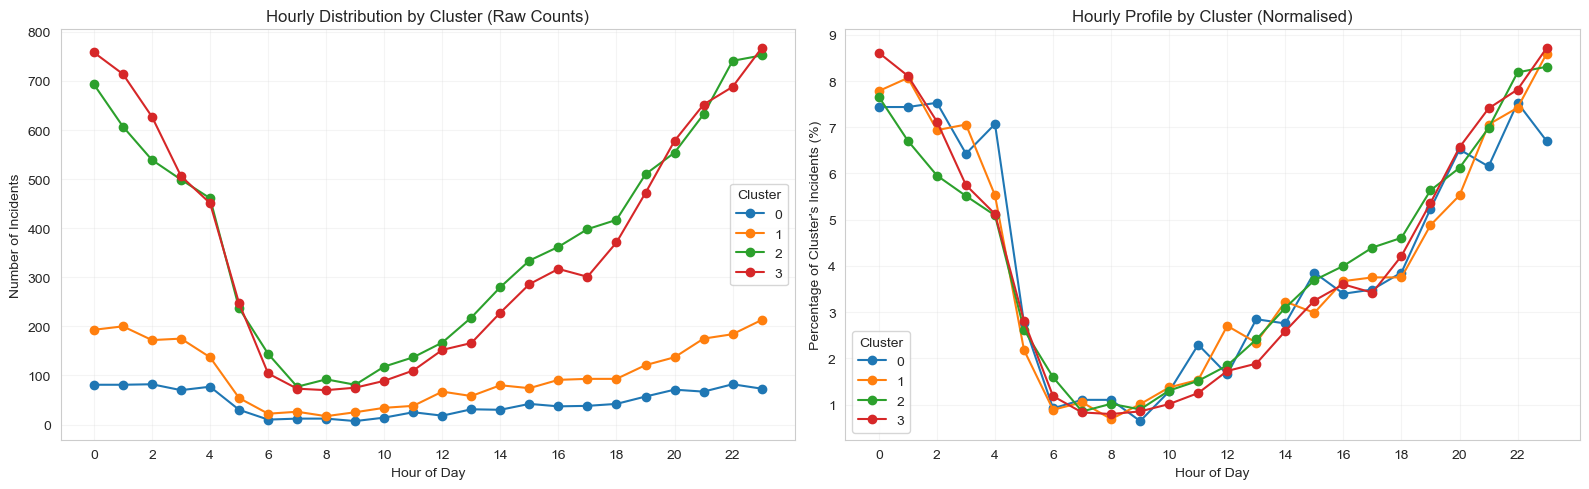

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_cluster.plot(ax=axes[0], marker='o')
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Incidents")
axes[0].set_title("Hourly Distribution by Cluster (Raw Counts)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(title="Cluster")
axes[0].grid(True, alpha=0.2)

hour_cluster_pct = hour_cluster.div(hour_cluster.sum(axis=0), axis=1) * 100
hour_cluster_pct.plot(ax=axes[1], marker='o')
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Percentage of Cluster's Incidents (%)")
axes[1].set_title("Hourly Profile by Cluster (Normalised)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(title="Cluster")
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Step 37 — Density-based clustering: DBSCAN

DBSCAN is used to look for groups of incidents based on local point density. Unlike K-Means, it can leave sparse observations as noise.

The main parameters are `eps`, the neighbourhood radius in feet, and `min_samples`, the minimum number of nearby observations needed to form a dense area.


## Step 38 — Selecting `eps` from the k-distance plot

The k-distance plot is used to choose a reasonable value of `eps`. The distance to the `min_samples`-th nearest neighbour is calculated for each point and then sorted.

Here, `min_samples` is set to 20. The main candidate for `eps` is taken from the visible change in the k-distance curve and then checked using the sensitivity analysis.


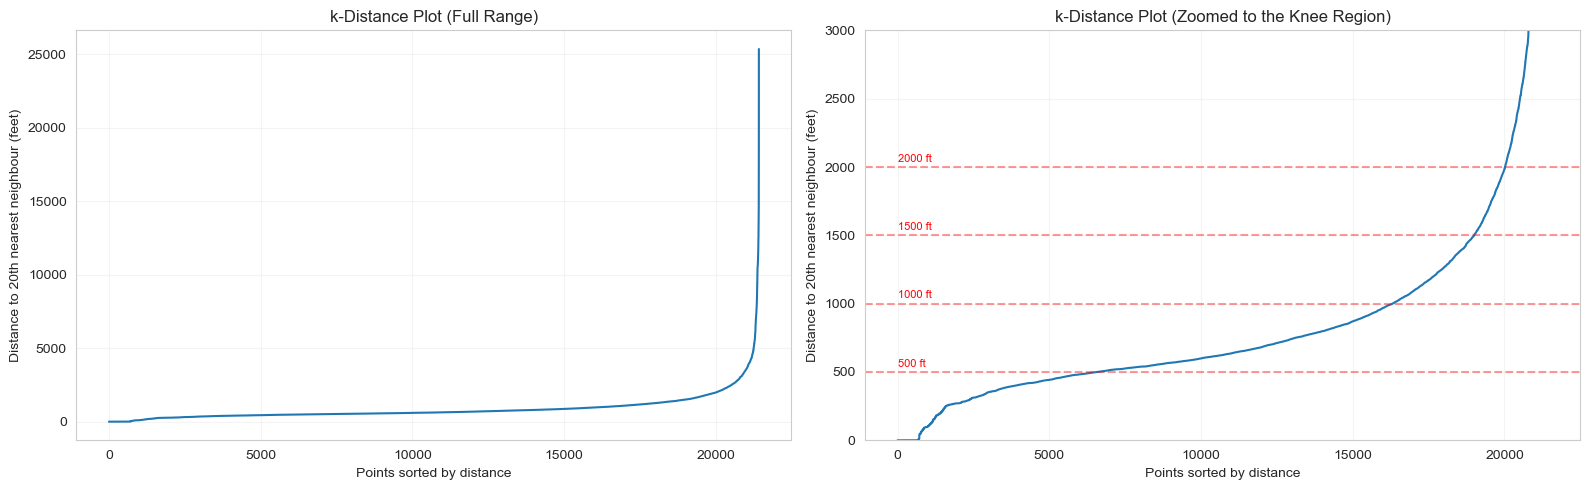

k-distance percentiles (feet):
  50th percentile: 624 ft  (190 m)
  75th percentile: 976 ft  (298 m)
  90th percentile: 1601 ft  (488 m)
  95th percentile: 2303 ft  (702 m)
  97th percentile: 2933 ft  (894 m)
  99th percentile: 4568 ft  (1392 m)


In [57]:
MIN_SAMPLES = 20

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_spatial)
distances, _ = nn.kneighbors(X_spatial)

kdist = np.sort(distances[:, -1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(kdist)
axes[0].set_xlabel("Points sorted by distance")
axes[0].set_ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour (feet)")
axes[0].set_title("k-Distance Plot (Full Range)")
axes[0].grid(alpha=0.2)

axes[1].plot(kdist)
axes[1].set_ylim(0, 3000)
axes[1].set_xlabel("Points sorted by distance")
axes[1].set_ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour (feet)")
axes[1].set_title("k-Distance Plot (Zoomed to the Knee Region)")
axes[1].grid(alpha=0.2)

for ref in [500, 1000, 1500, 2000]:
    axes[1].axhline(ref, color='red', linestyle='--', alpha=0.4)
    axes[1].text(0, ref + 40, f"{ref} ft", color='red', fontsize=8)

plt.tight_layout()
plt.show()

print("k-distance percentiles (feet):")
for p in [50, 75, 90, 95, 97, 99]:
    print(f"  {p}th percentile: {np.percentile(kdist, p):.0f} ft"
          f"  ({np.percentile(kdist, p) * FEET_TO_METRES:.0f} m)")

## Step 39 — Sensitivity analysis across `eps`

Several `eps` values are tested to see how the DBSCAN results change. The number of clusters, noise percentage, and cluster-size distribution are compared.

The silhouette score is included as a supporting metric, but the main focus is on whether the resulting spatial groups are stable and interpretable.


In [58]:
eps_values = [500, 750, 1000, 1250, 1500, 1750, 2000]
dbscan_results = []

for eps in eps_values:

    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = db.fit_predict(X_spatial)

    n_clusters = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100

    non_noise = labels != -1

    if n_clusters >= 2 and non_noise.sum() > 1:
        sil = silhouette_score(X_spatial[non_noise], labels[non_noise])
    else:
        sil = np.nan

    sizes = pd.Series(labels[non_noise]).value_counts()
    largest_share = sizes.max() / non_noise.sum() * 100 if n_clusters else np.nan
    tiny_clusters = (sizes < 50).sum() if n_clusters else 0

    dbscan_results.append({
        "eps_ft": eps,
        "eps_m": round(eps * FEET_TO_METRES),
        "clusters": n_clusters,
        "noise_pct": round(noise_pct, 2),
        "largest_cluster_pct": round(largest_share, 1),
        "clusters_under_50": tiny_clusters,
        "silhouette_UNRELIABLE": round(sil, 4) if not np.isnan(sil) else None
    })

dbscan_results_df = pd.DataFrame(dbscan_results)
print(dbscan_results_df.to_string(index=False))

print("\nNote: the silhouette column is reported for completeness only.")
print("It is not used for parameter selection - see the markdown above.")

 eps_ft  eps_m  clusters  noise_pct  largest_cluster_pct  clusters_under_50  silhouette_UNRELIABLE
    500    152       176      49.95                  5.4                112                 0.4163
    750    229        81      25.14                 36.1                 45                -0.0536
   1000    305        72      14.79                 36.7                 39                 0.0786
   1250    381        49       9.67                 40.9                 26                 0.0599
   1500    457        37       6.37                 40.5                 20                 0.1010
   1750    533        31       4.71                 40.1                  8                 0.1207
   2000    610        27       3.46                 39.7                  7                 0.1279

Note: the silhouette column is reported for completeness only.
It is not used for parameter selection - see the markdown above.


## Step 40 — Fit the selected DBSCAN model

The selected `eps` value is used to fit the final DBSCAN model. The output below reports the number of clusters, noise points, and the size of the largest cluster.


In [59]:
DBSCAN_EPS = 1250          # <-- set from the k-distance knee in Step 38

dbscan_final = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan_final.fit_predict(X_spatial)

n_clusters_db = len(set(dbscan_labels) - {-1})
n_noise_db = (dbscan_labels == -1).sum()

print(f"eps = {DBSCAN_EPS} ft ({DBSCAN_EPS * FEET_TO_METRES:.0f} m), "
      f"min_samples = {MIN_SAMPLES}")
print("-" * 50)
print("Clusters found:", n_clusters_db)
print("Noise points:", n_noise_db,
      f"({n_noise_db / len(dbscan_labels) * 100:.2f}%)")

sizes_db = pd.Series(dbscan_labels[dbscan_labels != -1]).value_counts()
print("\nLargest cluster:", sizes_db.max(),
      f"({sizes_db.max() / (dbscan_labels != -1).sum() * 100:.1f}% of clustered points)")
print("Clusters with fewer than 50 incidents:", (sizes_db < 50).sum())

print("\nTen largest clusters:")
print(sizes_db.head(10))

eps = 1250 ft (381 m), min_samples = 20
--------------------------------------------------
Clusters found: 49
Noise points: 2071 (9.67%)

Largest cluster: 7917 (40.9% of clustered points)
Clusters with fewer than 50 incidents: 26

Ten largest clusters:
0     7917
1     7718
14     741
8      283
9      215
19     210
11     191
18     167
16     148
13     104
Name: count, dtype: int64


### Step 40a — Chaining diagnostic

Step 41 (below) names the failure mode to watch for: if the two largest clusters together hold most of the clustered points, `eps` has chained through continuous urban density rather than isolating hotspots. That test is applied here, numerically, to the fitted result above, rather than left to visual inspection of the scatter plot.

In [60]:
top2_db = sizes_db.head(2).sum()
top2_share_db = top2_db / sizes_db.sum() * 100

print(f"Top two clusters combined: {top2_db} of {sizes_db.sum()} "
      f"clustered points ({top2_share_db:.1f}%)")

if top2_share_db > 50:
    print("\nCHAINING WARNING: the two largest clusters account for the "
          "majority of all clustered points. Per the criterion in Step 41, "
          "this eps has very likely chained through continuous urban "
          "density rather than isolating hotspots, regardless of the "
          "noise percentage or cluster count reported above.")
else:
    print("\nNo chaining flagged by this test.")


Top two clusters combined: 15635 of 19349 clustered points (80.8%)

CHAINING WARNING: the two largest clusters account for the majority of all clustered points. Per the criterion in Step 41, this eps has very likely chained through continuous urban density rather than isolating hotspots, regardless of the noise percentage or cluster count reported above.


The sweep in Step 39 shows this is not specific to `eps = 1250`: the largest-cluster share is small only at `eps = 500` (5.4%), where noise is ~50% and the solution fragments into 176 clusters, and it plateaus at 36–41% for every `eps` from 750 upward. No value in the swept range avoids chaining without over-fragmenting instead — this is the specific motivation for moving to HDBSCAN in Step 43, and the same test is applied to the HDBSCAN result in Step 48a.

## Step 41 — Visualise the DBSCAN result

Noise points are drawn separately in light grey so that the clustered structure is legible. Watch specifically for the failure mode described in Step 37: if two clusters together account for most of the clustered points, the algorithm has chained through continuous urban density rather than isolating hotspots, and `eps` is too large for this data. Reducing it will fragment the solution instead of resolving it — the underlying problem is that a single global `eps` cannot describe a city whose density varies from Midtown to Staten Island.

That limitation is what motivates HDBSCAN in Step 43.

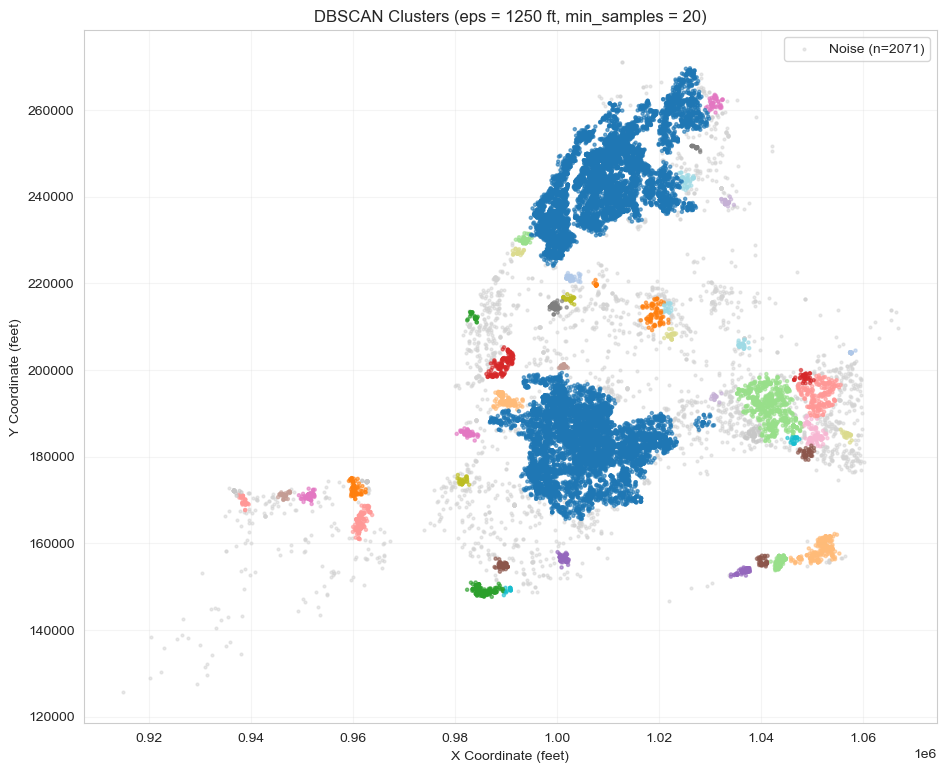

In [61]:
plt.figure(figsize=(11, 9))

noise_mask = dbscan_labels == -1

plt.scatter(
    X_spatial[noise_mask, 0],
    X_spatial[noise_mask, 1],
    c='lightgrey',
    s=4,
    alpha=0.5,
    label=f'Noise (n={noise_mask.sum()})'
)

plt.scatter(
    X_spatial[~noise_mask, 0],
    X_spatial[~noise_mask, 1],
    c=dbscan_labels[~noise_mask],
    cmap='tab20',
    s=5,
    alpha=0.6
)

plt.xlabel("X Coordinate (feet)")
plt.ylabel("Y Coordinate (feet)")
plt.title(f"DBSCAN Clusters (eps = {DBSCAN_EPS} ft, min_samples = {MIN_SAMPLES})")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Step 42 — Evaluate the DBSCAN solution

The DBSCAN solution is evaluated using the available clustering metrics on the non-noise observations. The results are used as part of the model comparison.


In [62]:
non_noise_mask = dbscan_labels != -1

X_db_eval = X_spatial[non_noise_mask]
labels_db_eval = dbscan_labels[non_noise_mask]

silhouette_dbscan = silhouette_score(X_db_eval, labels_db_eval)
davies_bouldin_dbscan = davies_bouldin_score(X_db_eval, labels_db_eval)
calinski_harabasz_dbscan = calinski_harabasz_score(X_db_eval, labels_db_eval)

print("DBSCAN Evaluation (non-noise points only)")
print("-" * 42)
print(f"Points evaluated:        {non_noise_mask.sum()}")
print(f"Silhouette Score:        {silhouette_dbscan:.4f}")
print(f"Davies-Bouldin Index:    {davies_bouldin_dbscan:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_dbscan:.2f}")

DBSCAN Evaluation (non-noise points only)
------------------------------------------
Points evaluated:        19349
Silhouette Score:        0.0599
Davies-Bouldin Index:    0.5035
Calinski-Harabasz Index: 4647.06


# Step 43 — HDBSCAN

HDBSCAN is tested because it can work with areas that have different local densities. It also identifies noise points without requiring one global density threshold for the whole dataset.

The main parameter considered here is `min_cluster_size`.


In [63]:
MIN_CLUSTER_SIZE = 50

hdb = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=10
)

hdb_labels = hdb.fit_predict(X_spatial)

n_clusters_hdb = len(set(hdb_labels) - {-1})
n_noise_hdb = (hdb_labels == -1).sum()

print(f"min_cluster_size = {MIN_CLUSTER_SIZE}")
print("-" * 40)
print("Clusters found:", n_clusters_hdb)
print("Noise points:", n_noise_hdb,
      f"({n_noise_hdb / len(hdb_labels) * 100:.2f}%)")

sizes_hdb = pd.Series(hdb_labels[hdb_labels != -1]).value_counts()
print("\nLargest cluster:", sizes_hdb.max(),
      f"({sizes_hdb.max() / (hdb_labels != -1).sum() * 100:.1f}% of clustered points)")
print("\nTen largest clusters:")
print(sizes_hdb.head(10))

min_cluster_size = 50
----------------------------------------
Clusters found: 56
Noise points: 3913 (18.27%)

Largest cluster: 8074 (46.1% of clustered points)

Ten largest clusters:
19    8074
20    2058
51     368
43     346
55     308
1      277
14     235
31     224
40     215
13     211
Name: count, dtype: int64


## Step 44 — Sensitivity to `min_cluster_size`

Because `min_cluster_size` encodes an analytical judgement about what counts as a hotspot, the solution is examined across a range of values rather than reported at a single setting.

Read the table against the purpose of the analysis. A small value produces many fine-grained clusters, some too small to act on; a large value returns a few broad areas that may be too coarse to be useful. The appropriate value is the one that yields hotspots at a scale a reader can interpret — comparable to a neighbourhood — with a noise rate that plausibly reflects genuinely isolated incidents.

In [64]:
hdb_results = []

for mcs in [25, 50, 75, 100, 150, 200]:

    h = HDBSCAN(min_cluster_size=mcs, min_samples=10)
    labels = h.fit_predict(X_spatial)

    n_cl = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    non_noise = labels != -1
    sizes = pd.Series(labels[non_noise]).value_counts()

    hdb_results.append({
        "min_cluster_size": mcs,
        "clusters": n_cl,
        "noise_pct": round(n_noise / len(labels) * 100, 2),
        "largest_cluster": int(sizes.max()) if n_cl else 0,
        "largest_pct": round(sizes.max() / non_noise.sum() * 100, 1) if n_cl else 0,
        "median_cluster_size": int(sizes.median()) if n_cl else 0
    })

hdb_results_df = pd.DataFrame(hdb_results)
print(hdb_results_df.to_string(index=False))

 min_cluster_size  clusters  noise_pct  largest_cluster  largest_pct  median_cluster_size
               25       216      37.89              224          1.7                   46
               50        56      18.27             8074         46.1                  117
               75        18       4.28             8313         40.5                  183
              100        13       4.51             8313         40.6                  235
              150        10       4.60             8313         40.7                  416
              200        12       8.64             8074         41.3                  560


## Step 45 — Visualise the HDBSCAN result

The comparison to make against Step 41 is whether the size distribution is more balanced — that is, whether the solution has moved away from two dominant blobs toward a set of clusters at interpretable, neighbourhood scale. That improvement, if present, is the practical benefit of allowing density to vary across the map.

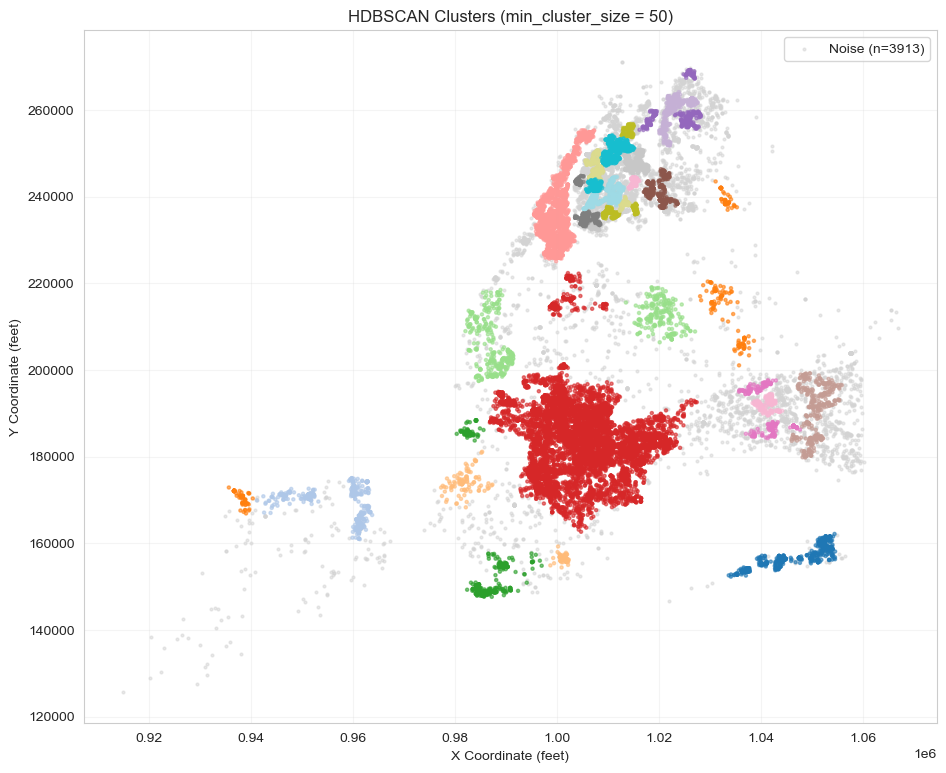

In [65]:
plt.figure(figsize=(11, 9))

noise_mask_h = hdb_labels == -1

plt.scatter(
    X_spatial[noise_mask_h, 0],
    X_spatial[noise_mask_h, 1],
    c='lightgrey',
    s=4,
    alpha=0.5,
    label=f'Noise (n={noise_mask_h.sum()})'
)

plt.scatter(
    X_spatial[~noise_mask_h, 0],
    X_spatial[~noise_mask_h, 1],
    c=hdb_labels[~noise_mask_h],
    cmap='tab20',
    s=5,
    alpha=0.6
)

plt.xlabel("X Coordinate (feet)")
plt.ylabel("Y Coordinate (feet)")
plt.title(f"HDBSCAN Clusters (min_cluster_size = {MIN_CLUSTER_SIZE})")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Step 46 — Evaluate the HDBSCAN solution

The same three metrics, computed on non-noise points, recorded for the comparison table. The same caution applies: these figures are comparable to the DBSCAN values, which share a density-based definition of a cluster, and are not comparable to the K-Means values.

In [66]:
non_noise_h = hdb_labels != -1

silhouette_hdbscan = silhouette_score(X_spatial[non_noise_h], hdb_labels[non_noise_h])
davies_bouldin_hdbscan = davies_bouldin_score(X_spatial[non_noise_h], hdb_labels[non_noise_h])
calinski_harabasz_hdbscan = calinski_harabasz_score(X_spatial[non_noise_h], hdb_labels[non_noise_h])

print("HDBSCAN Evaluation (non-noise points only)")
print("-" * 42)
print(f"Points evaluated:        {non_noise_h.sum()}")
print(f"Silhouette Score:        {silhouette_hdbscan:.4f}")
print(f"Davies-Bouldin Index:    {davies_bouldin_hdbscan:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_hdbscan:.2f}")

HDBSCAN Evaluation (non-noise points only)
------------------------------------------
Points evaluated:        17507
Silhouette Score:        0.3326
Davies-Bouldin Index:    0.6460
Calinski-Harabasz Index: 6763.40


## Step 47 — Do the density-based clusters recover the boroughs?

Step 34 applied this test to K-Means. It is applied again here, to the density-based solutions, so that the comparison is like-for-like.

A low ARI against `BORO` means the model has found structure that the administrative geography does not already encode — which is the outcome the analysis is looking for, and the respect in which a density-based solution would improve on the baseline.

In [67]:
ari_db_boro = adjusted_rand_score(
    boro_codes[dbscan_labels != -1],
    dbscan_labels[dbscan_labels != -1]
)

ari_hdb_boro = adjusted_rand_score(
    boro_codes[hdb_labels != -1],
    hdb_labels[hdb_labels != -1]
)

print("Adjusted Rand Index against BORO")
print("-" * 40)
print(f"K-Means (K=4):  {ari_kmeans_boro:.4f}")
print(f"DBSCAN:         {ari_db_boro:.4f}   (non-noise points)")
print(f"HDBSCAN:        {ari_hdb_boro:.4f}   (non-noise points)")
print()
print("Lower values indicate structure not already captured by borough.")

Adjusted Rand Index against BORO
----------------------------------------
K-Means (K=4):  0.6952
DBSCAN:         0.7316   (non-noise points)
HDBSCAN:        0.7476   (non-noise points)

Lower values indicate structure not already captured by borough.


# Step 48 — Model comparison

The K-Means, DBSCAN, and HDBSCAN results are compared using several criteria rather than one internal clustering score.

### Comparison criteria

| Criterion | Purpose |
|---|---|
| **ARI against `BORO`** | Checks how closely the clusters follow borough boundaries |
| **Noise handling** | Shows whether sparse observations can remain unassigned |
| **Cluster size distribution** | Checks whether the clusters are too large or too fragmented |
| **Geographic interpretability** | Checks whether the spatial groups are easy to describe |
| **Fit to the research question** | Checks whether the method describes local spatial concentrations |

Internal metrics are reported for reference, but they are not used as a universal ranking across different clustering algorithms.


In [68]:
comparison_df = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN", "HDBSCAN"],
    "Configuration": [
        "K = 4",
        f"eps = {DBSCAN_EPS} ft, min_samples = {MIN_SAMPLES}",
        f"min_cluster_size = {MIN_CLUSTER_SIZE}"
    ],
    "Clusters": [4, n_clusters_db, n_clusters_hdb],
    "Noise_Points": [0, n_noise_db, n_noise_hdb],
    "Noise_Pct": [
        0.00,
        round(n_noise_db / len(X_spatial) * 100, 2),
        round(n_noise_hdb / len(X_spatial) * 100, 2)
    ],
    "ARI_vs_BORO": [
        round(ari_kmeans_boro, 4),
        round(ari_db_boro, 4),
        round(ari_hdb_boro, 4)
    ],
    "Silhouette_NOT_COMPARABLE": [
        round(silhouette_k4, 4),
        round(silhouette_dbscan, 4),
        round(silhouette_hdbscan, 4)
    ],
    "DaviesBouldin_NOT_COMPARABLE": [
        round(davies_bouldin_k4, 4),
        round(davies_bouldin_dbscan, 4),
        round(davies_bouldin_hdbscan, 4)
    ]
})

print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)
print("The two metric columns are reported for completeness and are NOT")
print("used to rank the models. See the markdown above for the reasoning.")
print("=" * 70)

  Model                   Configuration  Clusters  Noise_Points  Noise_Pct  ARI_vs_BORO  Silhouette_NOT_COMPARABLE  DaviesBouldin_NOT_COMPARABLE
K-Means                           K = 4         4             0       0.00       0.6952                     0.6135                        0.6113
 DBSCAN eps = 1250 ft, min_samples = 20        49          2071       9.67       0.7316                     0.0599                        0.5035
HDBSCAN           min_cluster_size = 50        56          3913      18.27       0.7476                     0.3326                        0.6460

The two metric columns are reported for completeness and are NOT
used to rank the models. See the markdown above for the reasoning.


## Step 48a — Comparing the clustering results

The results from the previous steps are reviewed using the criteria above. Particular attention is given to the ARI against `BORO`, the amount of noise, and the size of the largest clusters.

This step records the main strengths and limitations of each density-based result before the final labels are selected.


## Step 48b — Does `cluster_selection_method='leaf'` break up the mega-cluster?

HDBSCAN's default cluster selection (`eom`, excess of mass) prefers the most stable clusters in the hierarchy, which tends to select a small number of large, persistent regions — exactly the behaviour producing Hotspot 19. `cluster_selection_method='leaf'` instead selects the leaves of the cluster tree directly, which produces more numerous, smaller, more homogeneous clusters at the cost of assigning more points to noise. It is fit at the same `min_cluster_size` for a direct comparison.

In [69]:
hdb_leaf = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=10,
    cluster_selection_method='leaf'
)
hdb_leaf_labels = hdb_leaf.fit_predict(X_spatial)

n_clusters_leaf = len(set(hdb_leaf_labels) - {-1})
n_noise_leaf = (hdb_leaf_labels == -1).sum()
non_noise_leaf = hdb_leaf_labels != -1
sizes_leaf = pd.Series(hdb_leaf_labels[non_noise_leaf]).value_counts()
top2_share_leaf = sizes_leaf.head(2).sum() / sizes_leaf.sum() * 100

ari_hdb_leaf_boro = adjusted_rand_score(
    boro_codes[non_noise_leaf],
    hdb_leaf_labels[non_noise_leaf]
)

print("HDBSCAN, cluster_selection_method='leaf'")
print("-" * 45)
print("Clusters found:", n_clusters_leaf)
print("Noise points:", n_noise_leaf,
      f"({n_noise_leaf / len(hdb_leaf_labels) * 100:.2f}%)")
print("Largest cluster:", sizes_leaf.max(),
      f"({sizes_leaf.max() / non_noise_leaf.sum() * 100:.1f}% of clustered points)")
print("Top two clusters combined:", f"{top2_share_leaf:.1f}% of clustered points")
print("ARI vs BORO:", round(ari_hdb_leaf_boro, 4))

print("\nComparison to the eom solution already fitted:")
print(pd.DataFrame({
    "cluster_selection_method": ["eom", "leaf"],
    "clusters": [n_clusters_hdb, n_clusters_leaf],
    "noise_pct": [
        round(n_noise_hdb / len(hdb_labels) * 100, 2),
        round(n_noise_leaf / len(hdb_leaf_labels) * 100, 2)
    ],
    "largest_cluster_pct": [
        round(sizes_hdb.max() / (hdb_labels != -1).sum() * 100, 1),
        round(sizes_leaf.max() / non_noise_leaf.sum() * 100, 1)
    ],
    "top2_pct": [
        round(sizes_hdb.head(2).sum() / sizes_hdb.sum() * 100, 1),
        round(top2_share_leaf, 1)
    ],
    "ari_vs_boro": [round(ari_hdb_boro, 4), round(ari_hdb_leaf_boro, 4)]
}).to_string(index=False))


HDBSCAN, cluster_selection_method='leaf'
---------------------------------------------
Clusters found: 119
Noise points: 8688 (40.56%)
Largest cluster: 368 (2.9% of clustered points)
Top two clusters combined: 5.1% of clustered points
ARI vs BORO: 0.0522

Comparison to the eom solution already fitted:
cluster_selection_method  clusters  noise_pct  largest_cluster_pct  top2_pct  ari_vs_boro
                     eom        56      18.27                 46.1      57.9       0.7476
                    leaf       119      40.56                  2.9       5.1       0.0522


### Step 48c — Selecting `FINAL_LABELS`

The final labels are taken from the density-based solution supported by the comparison in Step 48. The choice is based on the observed noise level, cluster-size distribution, borough relationship, and geographic interpretability.


## Step 49 — Hotspot profiling

The final spatial clusters are summarised using incident count, victim count, dominant borough, peak hour, and approximate spatial extent.

The profile helps describe the size and location of each final cluster.


In [70]:
FINAL_LABELS = hdb_labels          # <-- set per the decision rule in Step 48c
FINAL_MODEL_NAME = "HDBSCAN"       #     (use "HDBSCAN (leaf)" if hdb_leaf_labels is selected)

incident_df['Hotspot'] = FINAL_LABELS

hotspots = incident_df[incident_df['Hotspot'] != -1].copy()

hotspot_profile = (
    hotspots
    .groupby('Hotspot')
    .agg(
        Incidents=('INCIDENT_KEY', 'count'),
        Victims=('N_VICTIMS', 'sum'),
        Victims_Per_Incident=('N_VICTIMS', 'mean'),
        Centre_X=('X_COORD_CD', 'mean'),
        Centre_Y=('Y_COORD_CD', 'mean'),
        Dominant_Borough=('BORO', lambda s: s.mode().iloc[0]),
        Borough_Purity=('BORO', lambda s: s.value_counts(normalize=True).iloc[0] * 100),
        Peak_Hour=('Hour', lambda s: int(s.mode().iloc[0]))
    )
    .reset_index()
)

# Approximate radius, in feet: root-mean-square distance of each
# member point from its own cluster centre.
centres = (
    hotspots
    .groupby('Hotspot')[['X_COORD_CD', 'Y_COORD_CD']]
    .transform('mean')
)

sq_dist = (
    (hotspots['X_COORD_CD'] - centres['X_COORD_CD']) ** 2 +
    (hotspots['Y_COORD_CD'] - centres['Y_COORD_CD']) ** 2
)

spread = (
    np.sqrt(sq_dist.groupby(hotspots['Hotspot']).mean())
    .rename('Radius_ft')
    .reset_index()
)

hotspot_profile = hotspot_profile.merge(spread, on='Hotspot')
hotspot_profile['Radius_m'] = (hotspot_profile['Radius_ft'] * FEET_TO_METRES).round(0)

hotspot_profile = hotspot_profile.sort_values('Victims', ascending=False)

print(f"{FINAL_MODEL_NAME} hotspots, ranked by total victims")
print("=" * 70)
print(hotspot_profile.head(15).round(2).to_string(index=False))

HDBSCAN hotspots, ranked by total victims
 Hotspot  Incidents  Victims  Victims_Per_Incident   Centre_X  Centre_Y Dominant_Borough  Borough_Purity  Peak_Hour  Radius_ft  Radius_m
      19       8074     9991                  1.24 1004838.12 183646.23         BROOKLYN           98.97         23   10273.24    3131.0
      20       2058     2612                  1.27  999895.29 235306.59        MANHATTAN           99.90         23    6206.23    1892.0
      43        346      500                  1.45 1015645.83 247775.47            BRONX          100.00          0    1966.43     599.0
      51        368      493                  1.34 1012225.39 251811.76            BRONX          100.00         21    1701.71     519.0
      55        308      426                  1.38 1010899.06 240030.22            BRONX          100.00         23    1872.05     571.0
       1        277      350                  1.26 1051907.51 158778.03           QUEENS          100.00         23    2574.87     785.0

## Step 50 — Hotspot distribution across boroughs

How the identified hotspots distribute across the five boroughs, and what share of all incidents fall inside a hotspot versus in the noise class. This closes the loop with Step 34: if the hotspots cut across borough boundaries and concentrate unevenly within them, the density-based approach has produced something the administrative geography does not.

In [71]:
print("Hotspots per borough:")
print(hotspot_profile['Dominant_Borough'].value_counts())

print("\nIncidents inside a hotspot, by borough:")
inside = pd.crosstab(
    incident_df['BORO'],
    incident_df['Hotspot'] != -1,
    normalize='index'
) * 100
inside.columns = ['Noise (%)', 'In a hotspot (%)']
print(inside.round(2))

print("\nOverall:")
print("  Incidents in a hotspot:",
      (incident_df['Hotspot'] != -1).sum(),
      f"({(incident_df['Hotspot'] != -1).mean() * 100:.2f}%)")
print("  Victims in a hotspot:",
      int(incident_df.loc[incident_df['Hotspot'] != -1, 'N_VICTIMS'].sum()),
      f"({incident_df.loc[incident_df['Hotspot'] != -1, 'N_VICTIMS'].sum() / incident_df['N_VICTIMS'].sum() * 100:.2f}%)")

Hotspots per borough:
Dominant_Borough
BRONX            28
QUEENS           14
BROOKLYN          6
MANHATTAN         4
STATEN ISLAND     4
Name: count, dtype: int64

Incidents inside a hotspot, by borough:
               Noise (%)  In a hotspot (%)
BORO                                      
BRONX              33.64             66.36
BROOKLYN            2.98             97.02
MANHATTAN           8.15             91.85
QUEENS             39.36             60.64
STATEN ISLAND      21.16             78.84

Overall:
  Incidents in a hotspot: 17507 (81.73%)
  Victims in a hotspot: 22240 (81.43%)


# Step 51 — Temporal profiling of the final spatial clusters

The K-Means temporal analysis in Step 36 describes the broad administrative partition. This section repeats the temporal analysis using `FINAL_LABELS`, so the final density-based clusters can be examined at their actual spatial scale.

The analysis uses normalised percentages within each cluster. This avoids treating a larger cluster as having a stronger temporal pattern simply because it contains more incidents.


In [72]:
# Keep only final clustered incidents for temporal profiling.
final_temporal = incident_df[incident_df['Hotspot'] != -1].copy()

final_month = pd.crosstab(final_temporal['Month'], final_temporal['Hotspot'])
final_month_pct = final_month.div(final_month.sum(axis=0), axis=1) * 100

final_hour = pd.crosstab(final_temporal['Hour'], final_temporal['Hotspot'])
final_hour_pct = final_hour.div(final_hour.sum(axis=0), axis=1) * 100

print("Final clustered incidents:", len(final_temporal))
print("Number of final clusters:", final_temporal['Hotspot'].nunique())

print("\nMonthly distribution within each final cluster (%):")
print(final_month_pct.round(2).to_string())

print("\nHourly distribution within each final cluster (%):")
print(final_hour_pct.round(2).to_string())


Final clustered incidents: 17507
Number of final clusters: 56

Monthly distribution within each final cluster (%):
Hotspot     0      1      2      3      4      5      6      7      8      9      10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35     36     37     38     39     40     41     42     43     44     45     46     47     48     49     50     51     52     53     54     55
Month                                                                                                                                                                                                                                                                                                                                                                                                          
1         1.22   5.42   5.10   6.51   7.26   8.70   5.00   4.72   1.92  12.50   4.48 

C:\Users\DELL\AppData\Local\Temp\ipykernel_6512\2629115687.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


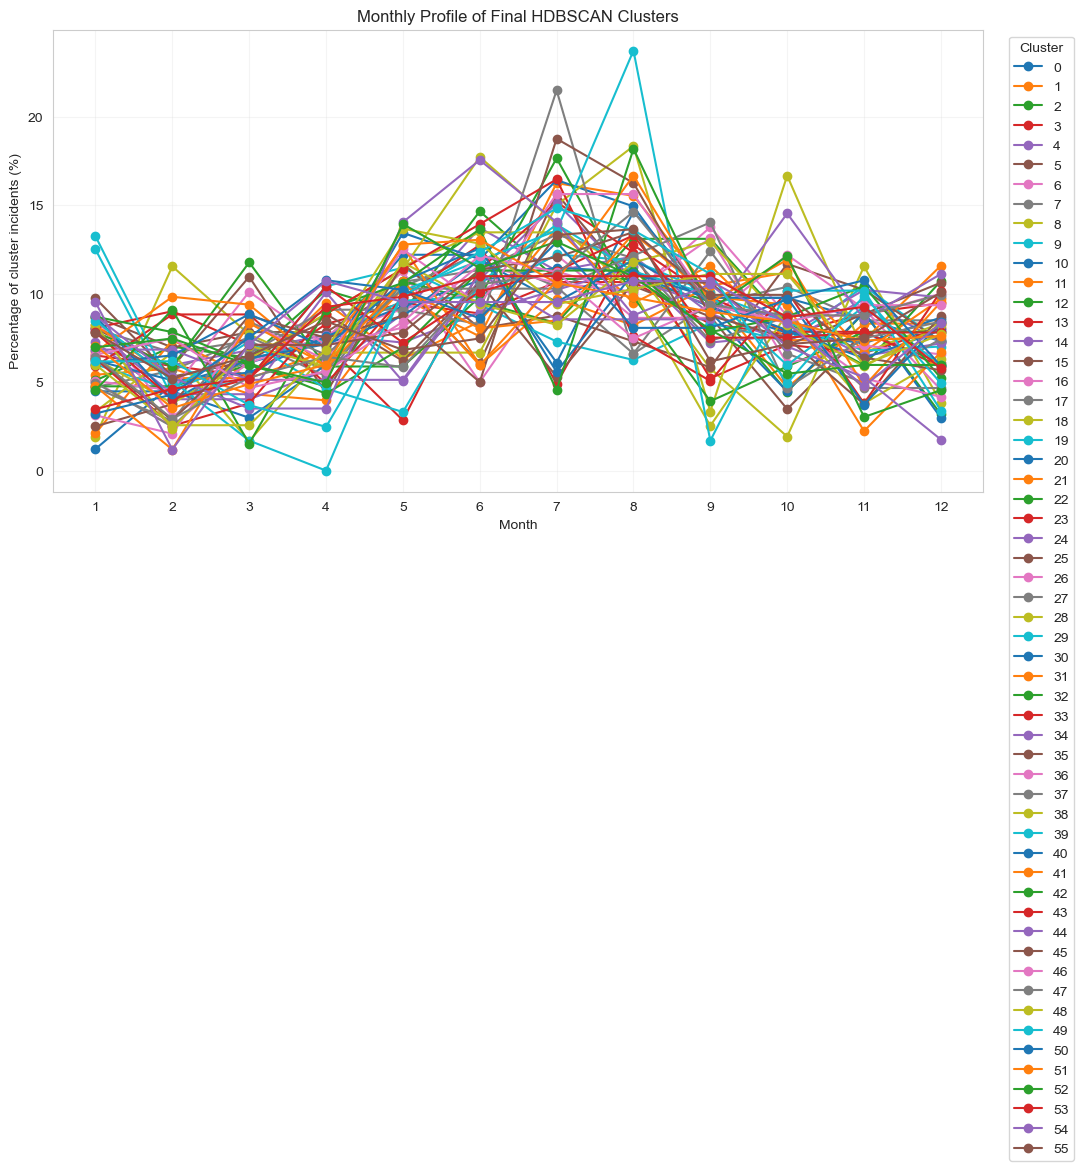

In [73]:
# Monthly temporal profile of the final clusters.
plt.figure(figsize=(12, 6))
final_month_pct.plot(marker='o', ax=plt.gca())
plt.xlabel("Month")
plt.ylabel("Percentage of cluster incidents (%)")
plt.title(f"Monthly Profile of Final {FINAL_MODEL_NAME} Clusters")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.2)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_6512\1484951850.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


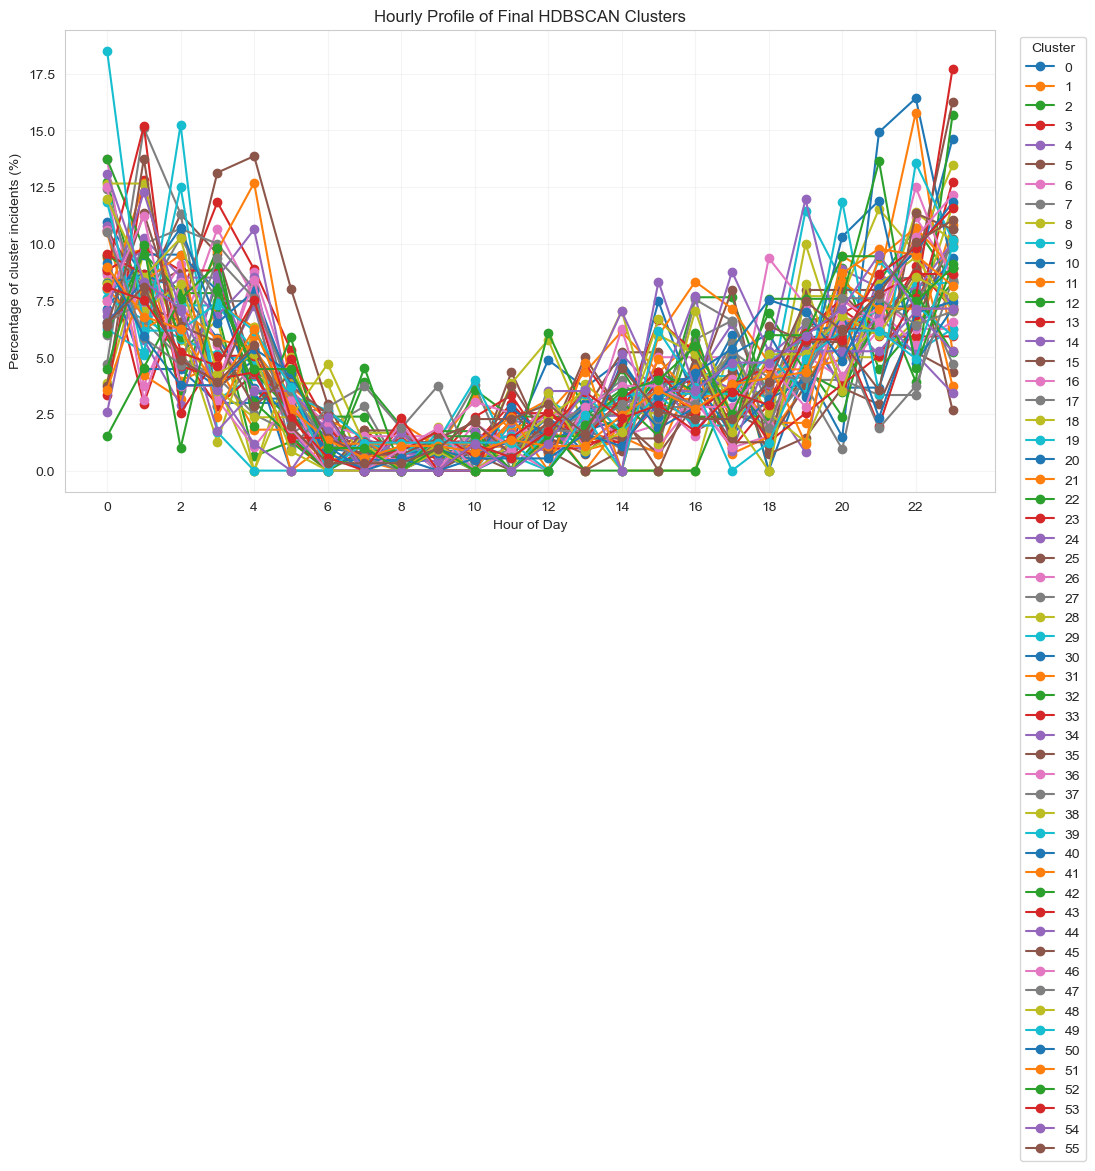

In [74]:
# Hourly temporal profile of the final clusters.
plt.figure(figsize=(12, 6))
final_hour_pct.plot(marker='o', ax=plt.gca())
plt.xlabel("Hour of Day")
plt.ylabel("Percentage of cluster incidents (%)")
plt.title(f"Hourly Profile of Final {FINAL_MODEL_NAME} Clusters")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.2)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Step 52 — Temporal stability of the final spatial clusters

The final clustering is cross-sectional: it uses all available years at once. To test whether the identified spatial structure persists, the incident-level data are split into two periods:

- **Period 1:** 2006–2013
- **Period 2:** 2014–2022

Each period is clustered independently using the selected HDBSCAN configuration. Cluster centres are then compared across periods. A close centre match is evidence that a similar spatial concentration appears in both periods; it is not proof that the exact same incidents or boundaries persist.


In [75]:
# Build independent period datasets using the same spatial feature definition.
period1 = incident_df[incident_df['Year'].between(2006, 2013)].copy()
period2 = incident_df[incident_df['Year'].between(2014, 2022)].copy()

X_p1 = period1[['X_COORD_CD', 'Y_COORD_CD']].values
X_p2 = period2[['X_COORD_CD', 'Y_COORD_CD']].values

print("Period 1 (2006–2013):", len(period1), "incidents")
print("Period 2 (2014–2022):", len(period2), "incidents")

# Use the same HDBSCAN family/configuration as the final model.
h1 = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=10)
h2 = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=10)

period1['Period_Cluster'] = h1.fit_predict(X_p1)
period2['Period_Cluster'] = h2.fit_predict(X_p2)

print("\nPeriod 1 clusters:", len(set(period1['Period_Cluster']) - {-1}))
print("Period 1 noise:", (period1['Period_Cluster'] == -1).sum())
print("Period 2 clusters:", len(set(period2['Period_Cluster']) - {-1}))
print("Period 2 noise:", (period2['Period_Cluster'] == -1).sum())


Period 1 (2006–2013): 11406 incidents
Period 2 (2014–2022): 10014 incidents

Period 1 clusters: 45
Period 1 noise: 3766
Period 2 clusters: 18
Period 2 noise: 1165


In [76]:
# Compare cluster centres across the two periods.
def cluster_centres(data, label_col='Period_Cluster'):
    clustered = data[data[label_col] != -1]
    return (
        clustered.groupby(label_col)[['X_COORD_CD', 'Y_COORD_CD']]
        .mean()
        .rename_axis('Cluster')
        .reset_index()
    )

centres1 = cluster_centres(period1)
centres2 = cluster_centres(period2)

if len(centres1) and len(centres2):
    C1 = centres1[['X_COORD_CD', 'Y_COORD_CD']].values
    C2 = centres2[['X_COORD_CD', 'Y_COORD_CD']].values

    # Pair every Period-1 cluster with its nearest Period-2 centre.
    nearest_rows = []
    for _, r in centres1.iterrows():
        d = np.sqrt(
            (C2[:, 0] - r['X_COORD_CD'])**2 +
            (C2[:, 1] - r['Y_COORD_CD'])**2
        )
        j = int(np.argmin(d))
        nearest_rows.append({
            'Period1_Cluster': int(r['Cluster']),
            'Nearest_Period2_Cluster': int(centres2.iloc[j]['Cluster']),
            'Centre_Distance_m': round(d[j] * FEET_TO_METRES, 0)
        })

    stability_table = pd.DataFrame(nearest_rows).sort_values('Centre_Distance_m')
    print("Nearest centre matches between periods:")
    print(stability_table.to_string(index=False))
else:
    stability_table = pd.DataFrame()
    print("Centre matching could not be calculated because one period has no non-noise clusters.")


Nearest centre matches between periods:
 Period1_Cluster  Nearest_Period2_Cluster  Centre_Distance_m
              12                        5               44.0
              10                       13               66.0
               0                        0               79.0
              20                       11              125.0
               3                        3              229.0
               2                        2              277.0
              43                       16              289.0
              40                       16              539.0
               1                        1              540.0
               6                        7              572.0
              19                       15              715.0
              42                       16              722.0
              33                       16              784.0
               5                        6              814.0
              44                       16    

### Interpretation rule for temporal stability

Centre matching is deliberately reported as a distance rather than converted into an arbitrary “stable/unstable” label. The table identifies which clusters in the first period have nearby spatial counterparts in the second period.

Because HDBSCAN is fitted independently, cluster IDs themselves have no meaning across periods. A match therefore depends on spatial proximity, not on the numerical cluster label.


# Step 53 — Severity profile of the final spatial clusters

The main clustering objective is **frequency of incidents**, because every incident is one spatial observation. Severity is therefore analysed separately rather than silently changing the clustering objective.

For each final cluster, the analysis reports:
- total incidents,
- total victims,
- average victims per incident,
- number and percentage of incidents marked as statistical murders.

This shows whether spatial concentrations of incidents also differ in victim burden or recorded severity.


In [77]:
severity_profile = (
    incident_df[incident_df['Hotspot'] != -1]
    .groupby('Hotspot')
    .agg(
        Incidents=('INCIDENT_KEY', 'count'),
        Victims=('N_VICTIMS', 'sum'),
        Mean_Victims_Per_Incident=('N_VICTIMS', 'mean'),
        Murder_Flagged_Incidents=('STATISTICAL_MURDER_FLAG', 'sum')
    )
    .reset_index()
)

severity_profile['Murder_Flagged_Pct'] = (
    severity_profile['Murder_Flagged_Incidents'] /
    severity_profile['Incidents'] * 100
)

severity_profile['Victims_Per_100_Incidents'] = (
    severity_profile['Victims'] /
    severity_profile['Incidents'] * 100
)

severity_profile = severity_profile.sort_values(
    ['Victims', 'Incidents'], ascending=False
)

print(f"Severity profile of final {FINAL_MODEL_NAME} clusters:")
print(severity_profile.round(2).to_string(index=False))


Severity profile of final HDBSCAN clusters:
 Hotspot  Incidents  Victims  Mean_Victims_Per_Incident  Murder_Flagged_Incidents  Murder_Flagged_Pct  Victims_Per_100_Incidents
      19       8074     9991                       1.24                      1393               17.25                     123.74
      20       2058     2612                       1.27                       305               14.82                     126.92
      43        346      500                       1.45                        55               15.90                     144.51
      51        368      493                       1.34                        62               16.85                     133.97
      55        308      426                       1.38                        54               17.53                     138.31
       1        277      350                       1.26                        49               17.69                     126.35
      14        235      313                       1.

Statistical-murder-flagged incidents: 3706


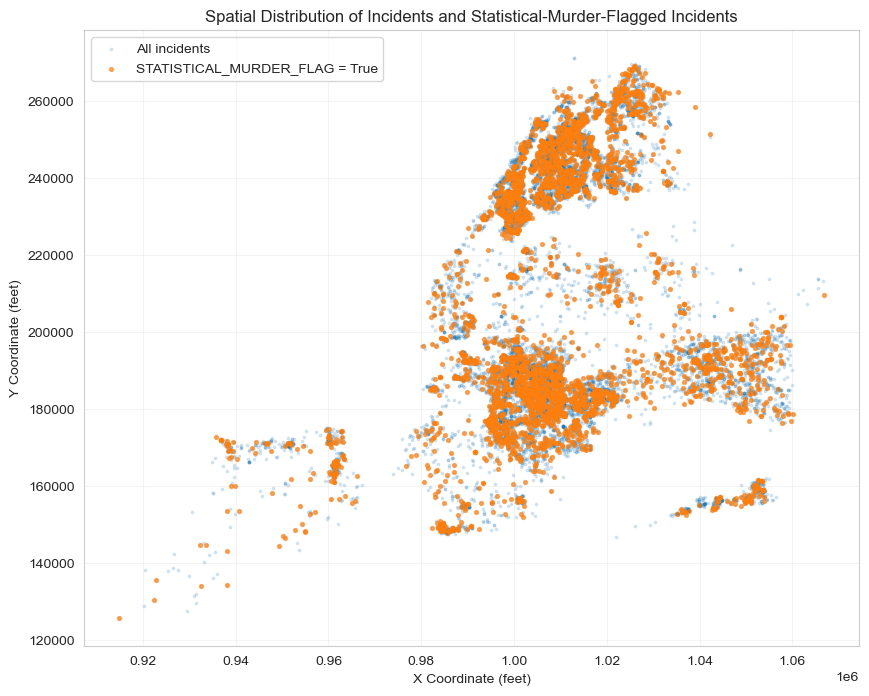

In [78]:
# Optional severity-focused spatial view:
# retain only incidents with STATISTICAL_MURDER_FLAG == True and inspect their locations.
murder_incidents = incident_df[
    (incident_df['STATISTICAL_MURDER_FLAG'] == True) &
    incident_df[['X_COORD_CD', 'Y_COORD_CD']].notna().all(axis=1)
].copy()

print("Statistical-murder-flagged incidents:", len(murder_incidents))

plt.figure(figsize=(10, 8))
plt.scatter(
    incident_df['X_COORD_CD'],
    incident_df['Y_COORD_CD'],
    s=3, alpha=0.15,
    label='All incidents'
)
plt.scatter(
    murder_incidents['X_COORD_CD'],
    murder_incidents['Y_COORD_CD'],
    s=8, alpha=0.6,
    label='STATISTICAL_MURDER_FLAG = True'
)
plt.xlabel("X Coordinate (feet)")
plt.ylabel("Y Coordinate (feet)")
plt.title("Spatial Distribution of Incidents and Statistical-Murder-Flagged Incidents")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


# Step 54 — Area-normalised descriptive density

The dataset itself does not contain a population denominator. Therefore, a population-adjusted rate cannot be calculated from this file alone.

A limited area-normalised measure can still be reported using the RMS radius already calculated in Step 49. The resulting value is a **descriptive density proxy**, not a population risk rate, because the RMS circle is an approximation of each cluster's spatial footprint.


In [79]:
density_profile = hotspot_profile.copy()

# Approximate circular area from the RMS radius.
density_profile['Approx_Area_km2'] = (
    np.pi * (density_profile['Radius_m'] / 1000) ** 2
)

density_profile['Incidents_per_km2_proxy'] = (
    density_profile['Incidents'] /
    density_profile['Approx_Area_km2'].replace(0, np.nan)
)

density_profile['Victims_per_km2_proxy'] = (
    density_profile['Victims'] /
    density_profile['Approx_Area_km2'].replace(0, np.nan)
)

print("Descriptive area-normalised profile (not a population risk rate):")
print(
    density_profile[
        ['Hotspot', 'Incidents', 'Victims', 'Radius_m',
         'Approx_Area_km2', 'Incidents_per_km2_proxy',
         'Victims_per_km2_proxy', 'Dominant_Borough']
    ].round(2).to_string(index=False)
)


Descriptive area-normalised profile (not a population risk rate):
 Hotspot  Incidents  Victims  Radius_m  Approx_Area_km2  Incidents_per_km2_proxy  Victims_per_km2_proxy Dominant_Borough
      19       8074     9991    3131.0            30.80                   262.16                 324.41         BROOKLYN
      20       2058     2612    1892.0            11.25                   183.00                 232.26        MANHATTAN
      43        346      500     599.0             1.13                   306.95                 443.57            BRONX
      51        368      493     519.0             0.85                   434.87                 582.59            BRONX
      55        308      426     571.0             1.02                   300.70                 415.90            BRONX
       1        277      350     785.0             1.94                   143.08                 180.79           QUEENS
      14        235      313    1208.0             4.58                    51.26       

# Step 55 — Final results table

This table combines the main findings needed for the project report: the selected model, cluster size, victim burden, borough composition, peak hour and approximate spatial extent.

Cluster IDs are model-specific labels. They should not be interpreted as an ordinal ranking. If a ranking is needed for reporting, use an explicit variable such as total victims or incident count.


In [80]:
final_results = hotspot_profile.merge(
    severity_profile[
        ['Hotspot', 'Murder_Flagged_Incidents', 'Murder_Flagged_Pct']
    ],
    on='Hotspot',
    how='left'
)

final_results['Model'] = FINAL_MODEL_NAME
final_results['Radius_m'] = final_results['Radius_m'].round(0)
final_results = final_results[
    [
        'Model', 'Hotspot', 'Incidents', 'Victims',
        'Victims_Per_Incident', 'Murder_Flagged_Incidents',
        'Murder_Flagged_Pct', 'Dominant_Borough',
        'Borough_Purity', 'Peak_Hour', 'Radius_m'
    ]
].sort_values('Victims', ascending=False)

print(final_results.round(2).to_string(index=False))


  Model  Hotspot  Incidents  Victims  Victims_Per_Incident  Murder_Flagged_Incidents  Murder_Flagged_Pct Dominant_Borough  Borough_Purity  Peak_Hour  Radius_m
HDBSCAN       19       8074     9991                  1.24                      1393               17.25         BROOKLYN           98.97         23    3131.0
HDBSCAN       20       2058     2612                  1.27                       305               14.82        MANHATTAN           99.90         23    1892.0
HDBSCAN       43        346      500                  1.45                        55               15.90            BRONX          100.00          0     599.0
HDBSCAN       51        368      493                  1.34                        62               16.85            BRONX          100.00         21     519.0
HDBSCAN       55        308      426                  1.38                        54               17.53            BRONX          100.00         23     571.0
HDBSCAN        1        277      350          

# Step 56 — Conclusions

The analysis can be summarised as follows:

1. The original data contains repeated incident keys because an incident can have multiple victim records.
2. An incident-level dataset was created while retaining the number of victims per incident.
3. K-Means was used as a baseline and compared with the borough structure.
4. DBSCAN and HDBSCAN were tested to identify spatial groups based on density.
5. The final clusters were examined by location, time, stability, severity, and cluster size.
6. The results describe spatial patterns in the dataset; they do not establish causes or individual-level risk.
7. Population-adjusted risk cannot be calculated from this dataset alone because a population denominator is not included.


In [81]:
# Automatically print a compact conclusion-ready summary.
print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)
print("Model:", FINAL_MODEL_NAME)
print("Total incidents:", len(incident_df))
print("Final clustered incidents:", int((incident_df['Hotspot'] != -1).sum()))
print("Final noise incidents:", int((incident_df['Hotspot'] == -1).sum()))
print("Final number of clusters:", int(incident_df.loc[incident_df['Hotspot'] != -1, 'Hotspot'].nunique()))

if not hotspot_profile.empty:
    print("\nFinal clusters ranked by total victims (reporting order only):")
    print(
        hotspot_profile[
            ['Hotspot', 'Incidents', 'Victims', 'Dominant_Borough',
             'Borough_Purity', 'Peak_Hour', 'Radius_m']
        ].head(15).round(2).to_string(index=False)
    )

print("\nKey limitations:")
print("• Coordinates define the clustering; clustering does not establish causation.")
print("• Population-adjusted risk is not calculated because no population denominator is included.")
print("• RMS radius is an approximate spatial-extent measure, not an administrative boundary.")
print("• Cluster IDs are labels, not ranks.")


FINAL PROJECT SUMMARY
Model: HDBSCAN
Total incidents: 21420
Final clustered incidents: 17507
Final noise incidents: 3913
Final number of clusters: 56

Final clusters ranked by total victims (reporting order only):
 Hotspot  Incidents  Victims Dominant_Borough  Borough_Purity  Peak_Hour  Radius_m
      19       8074     9991         BROOKLYN           98.97         23    3131.0
      20       2058     2612        MANHATTAN           99.90         23    1892.0
      43        346      500            BRONX          100.00          0     599.0
      51        368      493            BRONX          100.00         21     519.0
      55        308      426            BRONX          100.00         23     571.0
       1        277      350           QUEENS          100.00         23     785.0
      14        235      313           QUEENS          100.00          4    1208.0
      52        201      281            BRONX          100.00          1     392.0
      13        211      280         BR